In [4]:
# For a number of severe convective wind cases, plot the following:
#    -> Time series of the logistic model(s) developed by Brown and Dowdy (2021) from reanalysis
#    -> A time series of the contribution of each of the components of the model
#    -> A time series of a selection of other diagnostics such as the SCP, DCP, MBURST, MWPI, GUSTEX, etc.
#    -> Spatial maps at the time of observed wind damage
#    -> Time series or details of observed wind speeds/damage for each event
#    -> A skewT diagram for each case


# Cases in this notebook 

# VICTORIA
# -> Melbourne supercell storm, 2011
#         https://www.abc.net.au/news/2011-12-26/christmas-day-hail-storm-hits-melbourne/3747854?nw=0
# -> Cressy microburst, 2020
#         https://www.abc.net.au/news/2020-02-01/wild-weather-victoria-continues-across-victoria/11920502
# -> Melbourne cool-season squall line, 2009
#         http://www.bom.gov.au/weather-services/severe-weather-knowledge-centre/thunderstorm-reports/Severe_wind_event_Victoria_2-3_August_2009.pdf
# -> Melbourne warm-season squall line, 2015
#         https://www.abc.net.au/news/2015-02-28/victorian-storms-toddler-killed-girl-taken-hospital/6271536
# -> Melbourne cool-season squall line, 2020
#         https://www.abc.net.au/news/2020-08-27/weather-cold-front-sweeps-southern-victoria-bringing-wild-winds/12604088
# -> Ballarat squall line, 2020 (same day as Geelong tornado)
#         https://www.abc.net.au/news/2020-05-20/weather-storm-tears-roofs-off-homes-geelong-victoria/12265432
# -> Dandenong/Gippsland cut-off low, 2021 (see end of notebook for measured gusts vs. ERA5)
# -> Thunderstorm asthma event, 2016
# -> Severe thunderstorm, 2010
#         http://www.bom.gov.au/inside/services_policy/public/sevwx/vic/20100603_thunder.shtml

# NSW
# -> Boorowa squall line, 2020 (transmission towers down)
#         https://www.smh.com.au/national/nsw/thunderstorms-lash-sydney-after-sweltering-through-another-hot-day-20201201-p56jmj.html
#         https://www.hilltopsphoenix.com.au/hilltops-recovery-effort-after-massive-storm/
# -> Sydney severe thunderstorm, 2016
#         https://www.abc.net.au/news/2016-01-14/man-dies-as-severe-thunderstorm-hits-sydney/7089142?nw=0

# QLD
# -> Winton unusual downburst, 2016
# -> Double Island Point supercell, 2006 (53 m/s measured)
#         https://www.ga.gov.au/scientific-topics/community-safety/severe-wind
# -> The Gap supercell storm, 2008
# -> Oakey squall line, 2011
# -> Archerfield supercell, 2014
#         http://www.bom.gov.au/announcements/sevwx/qld/qldts20141127/qldts20141127.shtml

In [5]:
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import sharppy.plot.skew as skew
from sharppy.sharptab import winds, utils, params, thermo, interp, profile
from sharppy.io.spc_decoder import SPCDecoder
import xarray as xr
from metpy.calc import dewpoint_from_relative_humidity
import glob
from matplotlib import gridspec
from matplotlib.ticker import ScalarFormatter, MultipleLocator
import pyart
import cartopy.crs as ccrs
import warnings; warnings.simplefilter("ignore")
import zipfile
from IPython.display import display, Markdown



## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [6]:
#Code to register the "skewx" projection, from here https://matplotlib.org/stable/gallery/specialty_plots/skewt.html

from contextlib import ExitStack

from matplotlib.axes import Axes
import matplotlib.transforms as transforms
import matplotlib.axis as maxis
import matplotlib.spines as mspines
from matplotlib.projections import register_projection


# The sole purpose of this class is to look at the upper, lower, or total
# interval as appropriate and see what parts of the tick to draw, if any.
class SkewXTick(maxis.XTick):
    def draw(self, renderer):
        # When adding the callbacks with `stack.callback`, we fetch the current
        # visibility state of the artist with `get_visible`; the ExitStack will
        # restore these states (`set_visible`) at the end of the block (after
        # the draw).
        with ExitStack() as stack:
            for artist in [self.gridline, self.tick1line, self.tick2line,
                           self.label1, self.label2]:
                stack.callback(artist.set_visible, artist.get_visible())
            needs_lower = transforms.interval_contains(
                self.axes.lower_xlim, self.get_loc())
            needs_upper = transforms.interval_contains(
                self.axes.upper_xlim, self.get_loc())
            self.tick1line.set_visible(
                self.tick1line.get_visible() and needs_lower)
            self.label1.set_visible(
                self.label1.get_visible() and needs_lower)
            self.tick2line.set_visible(
                self.tick2line.get_visible() and needs_upper)
            self.label2.set_visible(
                self.label2.get_visible() and needs_upper)
            super().draw(renderer)

    def get_view_interval(self):
        return self.axes.xaxis.get_view_interval()


# This class exists to provide two separate sets of intervals to the tick,
# as well as create instances of the custom tick
class SkewXAxis(maxis.XAxis):
    def _get_tick(self, major):
        return SkewXTick(self.axes, None, major=major)

    def get_view_interval(self):
        return self.axes.upper_xlim[0], self.axes.lower_xlim[1]


# This class exists to calculate the separate data range of the
# upper X-axis and draw the spine there. It also provides this range
# to the X-axis artist for ticking and gridlines
class SkewSpine(mspines.Spine):
    def _adjust_location(self):
        pts = self._path.vertices
        if self.spine_type == 'top':
            pts[:, 0] = self.axes.upper_xlim
        else:
            pts[:, 0] = self.axes.lower_xlim


# This class handles registration of the skew-xaxes as a projection as well
# as setting up the appropriate transformations. It also overrides standard
# spines and axes instances as appropriate.
class SkewXAxes(Axes):
    # The projection must specify a name.  This will be used be the
    # user to select the projection, i.e. ``subplot(projection='skewx')``.
    name = 'skewx'

    def _init_axis(self):
        # Taken from Axes and modified to use our modified X-axis
        self.xaxis = SkewXAxis(self)
        self.spines.top.register_axis(self.xaxis)
        self.spines.bottom.register_axis(self.xaxis)
        self.yaxis = maxis.YAxis(self)
        self.spines.left.register_axis(self.yaxis)
        self.spines.right.register_axis(self.yaxis)

    def _gen_axes_spines(self):
        spines = {'top': SkewSpine.linear_spine(self, 'top'),
                  'bottom': mspines.Spine.linear_spine(self, 'bottom'),
                  'left': mspines.Spine.linear_spine(self, 'left'),
                  'right': mspines.Spine.linear_spine(self, 'right')}
        return spines

    def _set_lim_and_transforms(self):
        """
        This is called once when the plot is created to set up all the
        transforms for the data, text and grids.
        """
        rot = 30

        # Get the standard transform setup from the Axes base class
        super()._set_lim_and_transforms()

        # Need to put the skew in the middle, after the scale and limits,
        # but before the transAxes. This way, the skew is done in Axes
        # coordinates thus performing the transform around the proper origin
        # We keep the pre-transAxes transform around for other users, like the
        # spines for finding bounds
        self.transDataToAxes = (
            self.transScale
            + self.transLimits
            + transforms.Affine2D().skew_deg(rot, 0)
        )
        # Create the full transform from Data to Pixels
        self.transData = self.transDataToAxes + self.transAxes

        # Blended transforms like this need to have the skewing applied using
        # both axes, in axes coords like before.
        self._xaxis_transform = (
            transforms.blended_transform_factory(
                self.transScale + self.transLimits,
                transforms.IdentityTransform())
            + transforms.Affine2D().skew_deg(rot, 0)
            + self.transAxes
        )

    @property
    def lower_xlim(self):
        return self.axes.viewLim.intervalx

    @property
    def upper_xlim(self):
        pts = [[0., 1.], [1., 1.]]
        return self.transDataToAxes.inverted().transform(pts)[:, 0]


# Now register the projection with matplotlib so the user can select it.
register_projection(SkewXAxes)

def calc_logit(ds):
    ds = ds.assign(logit_barra_aws= 1 / 
                   ( 1 + np.exp( -(1.2e-01*ds["ebwd"] + 9.9e-01*ds["lr13"] + 2.1e-01*ds["Umean03"] + 2.4e-04*ds["ml_el"] +
                                   2.0e-02*ds["rhmin03"]  - 1.2e+01 ) ) ) )
    ds = ds.assign(logit_barra_sta = 1 / 
                    ( 1 + np.exp( -(8.8e-02*ds["ebwd"] + 1.8e-01*ds["Umean800_600"] + 4.2e-01*ds["lr13"] + 2.2e-04*ds["ml_el"] +
                                    1.1e-02*ds["rhmin13"] - 7.4 ) ) ) )
    ds = ds.assign(logit_era5_aws = 1 / 
                   ( 1 + np.exp( -(6.1e-02*ds["ebwd"] + 1.5e-01*ds["Umean800_600"] + 9.4e-01*ds["lr13"] + 3.9e-02*ds["rhmin13"] +
                                   1.7e-02*ds["srhe_left"] +3.8e-01*ds["q_melting"] +4.7e-04*ds["eff_lcl"] - 1.3e+01 ) ) ) )
    ds = ds.assign(logit_era5_sta = 1 / ( 1 + np.exp( -(1.3e-01*ds["ebwd"] + 1.7e-01*ds["Umean06"] + 1.6e-03*ds["ml_cape"]+
                                    4.1e-01*ds["lr13"] - 5.6 ) ) ) )
    return ds
    
def components_barra_aws(ebwd, lr13, Umean03, ml_el, rhmin03):
    P = 1 / ( 1 + np.exp( -(1.2e-01*ebwd + 9.9e-01*lr13 + 2.1e-01*Umean03 + 2.4e-04*ml_el + 2.0e-02*rhmin03  - 1.2e+01 ) ) )

    z = 1.2e-01*ebwd + 9.9e-01*lr13 + 2.1e-01*Umean03 + 2.4e-04*ml_el + 2.0e-02*rhmin03
        
    x = np.log(P/(1-P)) + 12
    
    x1 = 1.2e-01*ebwd / x * P
    x2 = 9.9e-01*lr13 / x * P
    x3 = 2.1e-01*Umean03 / x * P
    x4 = 2.4e-04*ml_el / x * P
    x5 = 2.0e-02*rhmin03 / x * P

    return [x1,x2,x3,x4,x5]
    
def components_era5_aws(ebwd, Umean800_600, lr13, rhmin13, srhe_left, q_melting, eff_lcl):
    P = 1 / ( 1 + np.exp( -(6.1e-02*ebwd + 1.5e-01*Umean800_600 + 9.4e-01*lr13 + 3.9e-02*rhmin13 + 1.7e-02*srhe_left +3.8e-01*q_melting +4.7e-04*eff_lcl - 1.3e+01 ) ) )

    z = 6.1e-02*ebwd + 1.5e-01*Umean800_600 + 9.4e-01*lr13 + 3.9e-02*rhmin13 + 1.7e-02*srhe_left +3.8e-01*q_melting +4.7e-04*eff_lcl
        
    x = np.log(P/(1-P)) + 13
    
    x1 = 6.1e-02*ebwd / x * P
    x2 = 1.5e-01*Umean800_600 / x * P
    x3 = 9.4e-01*lr13 / x * P
    x4 = 3.9e-02*rhmin13 / x * P
    x5 = 1.7e-02*srhe_left / x * P
    x6 = 3.8e-01*q_melting / x * P
    x7 = 4.7e-04*eff_lcl / x * P

#    print(np.corrcoef(P, lr13)[0])
    
    return [x1,x2,x3,x4,x5,x6,x7]

def components_era5_sta(ebwd, Umean06, ml_cape, lr13):
    
    P = 1 / ( 1 + np.exp( -(1.3e-01*ebwd + 1.7e-01*Umean06 + 1.6e-03*ml_cape+ 4.1e-01*lr13 - 5.6 ) ) )
    
    z = 1.3e-01*ebwd + 1.7e-01*Umean06 + 1.6e-03*ml_cape+ 4.1e-01*lr13
    
    x = np.log(P/(1-P)) + 5.6
    
    x1 = 1.3e-01*ebwd / x * P
    x2 = 1.7e-01*Umean06 / x * P
    x3 = 1.6e-03*ml_cape / x * P
    x4 = 4.1e-01*lr13 / x * P
    
    return [x1,x2,x3,x4]

def plot_barra_aws_ts(f2):
    f2 = calc_logit(f2)
    x1,x2,x3,x4,x5 = components_barra_aws(f2["ebwd"], f2["lr13"], f2["Umean03"], f2["ml_el"], f2["rhmin03"])
    f2["logit_barra_aws"].plot()
    x1.plot(label="ebwd")
    x2.plot(label="lr13")
    x3.plot(label="Umean03")
    x4.plot(label="ml_el")
    x5.plot(label="rhmin03")
    plt.legend()

def plot_era5_aws_ts(f2, time):
    f2 = calc_logit(f2)
    x1,x2,x3,x4,x5,x6,x7 = components_era5_aws(f2["ebwd"], f2["Umean800_600"], f2["lr13"], f2["rhmin13"], f2["srhe_left"], f2["q_melting"], f2["eff_lcl"])
    f2["logit_era5_aws"].plot(color="k")
    x1.plot(label="ebwd", ls="--", color="tab:blue")
    x2.plot(label="Umean800_600", ls="--", color="tab:orange")
    x3.plot(label="lr13", ls="--", color="tab:green")
    x4.plot(label="rhmin13", ls="--", color="tab:red")
    x5.plot(label="srhe_left", ls="--", color="tab:brown")
    x6.plot(label="q_melting", ls="--", color="tab:pink")
    x7.plot(label="eff_lcl", ls="--", color="tab:gray")
    plt.title("Logistic model trained on measured events")
    plt.gca().axhline(0.83, color="tab:blue", ls=":")
    [plt.gca().axvline(t, color="k", ls="--", lw=1) for t in time]
    plt.legend()    

def plot_era5_sta_ts(f2, time):
    f2 = calc_logit(f2)
    x1,x2,x3,x4 = components_era5_sta(f2["ebwd"], f2["Umean06"], f2["ml_cape"], f2["lr13"])
    f2["logit_era5_sta"].plot(color="k")
    x1.plot(label="ebwd", ls="--", color="tab:blue")
    x2.plot(label="Umean06", ls="--", color="tab:orange")
    x3.plot(label="ml_cape", ls="--", color="tab:purple")
    x4.plot(label="lr13", ls="--", color="tab:green")
    plt.title("Logistic model trained on reported events")    
    plt.gca().axhline(0.72, color="tab:blue", ls=":")
    [plt.gca().axvline(t, color="k", ls="--", lw=1) for t in time]     
    plt.legend()    
    
def plot_era5_aws_spatial(f2, time, ax, lat, lon, domain="Melbourne"):
    
    if domain=="Melbourne":
        ylim=[-45,-30]; xlim=[136,150]
    elif domain=="Sydney":
        xlim=[145, 155]; ylim=[-37.5, -30]       
    elif domain=="Brisbane":
        ylim=[-29,-16]; xlim=[141,154]        
    f2 = calc_logit(f2)
    f2 = f2.sel({"time":time.replace(minute=0)})
    xr.plot.contourf(f2["logit_era5_aws"], levels=np.arange(0,1.1,.1), ylim=ylim, xlim=xlim, ax=ax, cmap=plt.get_cmap("Reds"), vmin=0, vmax=1)    
    xr.plot.contourf(xr.where(f2["logit_era5_aws"] > 0.83, 1, 0), 
                    ylim=ylim, xlim=xlim, ax=ax, 
                    levels=[.5,1.5], hatches=["","///"], colors=["none","none"],
                        add_colorbar=False)    
    plt.plot(lon, lat, color="k", marker="x", mew=3, ms=12)    
    plt.gca().coastlines()
    
def plot_era5_sta_spatial(f2, time, ax, lat, lon, domain="Melbourne"):
    
    if domain=="Melbourne":
        ylim=[-45,-30]; xlim=[136,150]
    elif domain=="Sydney":
        xlim=[145, 155]; ylim=[-37.5, -30]               
    elif domain=="Brisbane":
        ylim=[-29,-16]; xlim=[141,154]
    f2 = calc_logit(f2)
    f2 = f2.sel({"time":time.replace(minute=0)})
    xr.plot.contourf(f2["logit_era5_sta"], levels=np.arange(0,1.1,.1), ylim=ylim, xlim=xlim, ax=ax, cmap=plt.get_cmap("Reds"), vmin=0, vmax=1)    
    xr.plot.contourf(xr.where(f2["logit_era5_sta"] > 0.72, 1, 0), 
                    ylim=ylim, xlim=xlim, ax=ax, 
                    levels=[.5,1.5], hatches=["","///"], colors=["none","none"],
                        add_colorbar=False)   
    plt.plot(lon, lat, color="k", marker="x", mew=3, ms=12)
    plt.gca().coastlines()   
    
def plot_other_indices(f2, var, time):
    for v in var:
            f2[v].plot(label=v)
            if v == "dcp":
                plt.gca().axhline(1, color="tab:blue", ls=":")
            if v == "mlcape*s06":
                plt.gca().axhline(25000, color="tab:blue", ls=":")                
                plt.gca().axhline(68000, color="tab:blue", ls=":")                                
    plt.legend()
    [plt.gca().axvline(t, color="k", ls="--", lw=1) for t in time]  
    
def plot_sounding(time, lat, lon, cds=False, cds_pres_fname="", cds_sfc_fname=""):
    
    if cds:
        pres = xr.open_dataset(cds_pres_fname)
        sfc = xr.open_dataset(cds_sfc_fname)        
        z=pres["z"].sel({"time":time.replace(minute=0)}).interp({"longitude":lon, "latitude":lat},method="nearest")
        t=pres["t"].sel({"time":time.replace(minute=0)}).interp({"longitude":lon, "latitude":lat},method="nearest")
        r=pres["r"].sel({"time":time.replace(minute=0)}).interp({"longitude":lon, "latitude":lat},method="nearest")
        u=pres["u"].sel({"time":time.replace(minute=0)}).interp({"longitude":lon, "latitude":lat},method="nearest")
        v=pres["v"].sel({"time":time.replace(minute=0)}).interp({"longitude":lon, "latitude":lat},method="nearest")

        ts=sfc["t2m"].sel({"time":time.replace(minute=0)}).interp({"longitude":lon, "latitude":lat},method="nearest")    
        dps=sfc["d2m"].sel({"time":time.replace(minute=0)}).interp({"longitude":lon, "latitude":lat},method="nearest")    
        us=sfc["u10"].sel({"time":time.replace(minute=0)}).interp({"longitude":lon, "latitude":lat},method="nearest")    
        vs=sfc["v10"].sel({"time":time.replace(minute=0)}).interp({"longitude":lon, "latitude":lat},method="nearest")    
        ps=sfc["sp"].sel({"time":time.replace(minute=0)}).interp({"longitude":lon, "latitude":lat},method="nearest")    
        zs=sfc["z"].sel({"time":time.replace(minute=0)}).interp({"longitude":lon, "latitude":lat},method="nearest")   
    
    else:
        str_fmt = "/g/data/rt52/era5/pressure-levels/reanalysis/%s/%d/%s_era5_oper_pl_%s*.nc" 
        str_fmt_sfc = "/g/data/rt52/era5/single-levels/reanalysis/%s/%d/%s_era5_oper_sfc_%s*.nc"                 
        z=xr.open_dataset(glob.glob(str_fmt % ("z",time.year,"z",time.strftime("%Y%m01")))[0])["z"].\
                sel({"time":time.replace(minute=0)}).interp({"longitude":lon, "latitude":lat},method="nearest")
        t=xr.open_dataset(glob.glob(str_fmt % ("t",time.year,"t",time.strftime("%Y%m01")))[0])["t"].\
                sel({"time":time.replace(minute=0)}).interp({"longitude":lon, "latitude":lat},method="nearest")
        r=xr.open_dataset(glob.glob(str_fmt % ("r",time.year,"r",time.strftime("%Y%m01")))[0])["r"].\
                sel({"time":time.replace(minute=0)}).interp({"longitude":lon, "latitude":lat},method="nearest")
        u=xr.open_dataset(glob.glob(str_fmt % ("u",time.year,"u",time.strftime("%Y%m01")))[0])["u"].\
                sel({"time":time.replace(minute=0)}).interp({"longitude":lon, "latitude":lat},method="nearest")
        v=xr.open_dataset(glob.glob(str_fmt % ("v",time.year,"v",time.strftime("%Y%m01")))[0])["v"].\
                sel({"time":time.replace(minute=0)}).interp({"longitude":lon, "latitude":lat},method="nearest")

        ts=xr.open_dataset(glob.glob(str_fmt_sfc % ("2t",time.year,"2t",time.strftime("%Y%m01")))[0])["t2m"].\
                sel({"time":time.replace(minute=0)}).interp({"longitude":lon, "latitude":lat},method="nearest")    
        dps=xr.open_dataset(glob.glob(str_fmt_sfc % ("2d",time.year,"2d",time.strftime("%Y%m01")))[0])["d2m"].\
                sel({"time":time.replace(minute=0)}).interp({"longitude":lon, "latitude":lat},method="nearest")    
        us=xr.open_dataset(glob.glob(str_fmt_sfc % ("10u",time.year,"10u",time.strftime("%Y%m01")))[0])["u10"].\
                sel({"time":time.replace(minute=0)}).interp({"longitude":lon, "latitude":lat},method="nearest")    
        vs=xr.open_dataset(glob.glob(str_fmt_sfc % ("10v",time.year,"10v",time.strftime("%Y%m01")))[0])["v10"].\
                sel({"time":time.replace(minute=0)}).interp({"longitude":lon, "latitude":lat},method="nearest")    
        ps=xr.open_dataset(glob.glob(str_fmt_sfc % ("sp",time.year,"sp",time.strftime("%Y%m01")))[0])["sp"].\
                sel({"time":time.replace(minute=0)}).interp({"longitude":lon, "latitude":lat},method="nearest")    
        zs=xr.open_dataset(glob.glob(str_fmt_sfc % ("z",time.year,"z",time.strftime("%Y%m01")))[0])["z"].\
                sel({"time":time.replace(minute=0)}).interp({"longitude":lon, "latitude":lat},method="nearest")   
    
    p=z.level
    dp=dewpoint_from_relative_humidity(t,r)
    prof_pres = np.flip(p.values.squeeze())
    prof_hgt = np.flip(z.values.squeeze()/9.8)
    prof_tmpc = np.flip(t.values.squeeze()-273.15)
    prof_dwpc = np.flip(np.array(dp).squeeze())
    prof_u = np.flip(u.values.squeeze()*1.94)
    prof_v = np.flip(v.values.squeeze()*1.94)
    agl_inds = prof_pres <= (ps.values/100.)
    prof = profile.create_profile(pres=np.insert(prof_pres[agl_inds], 0, ps.values/100.),
                                  hght=np.insert(prof_hgt[agl_inds], 0, zs.values/9.8),
                                  tmpc=np.insert(prof_tmpc[agl_inds], 0, ts.values-273.15),
                                  dwpc=np.insert(prof_dwpc[agl_inds], 0, dps.values-273.15),
                                  u=np.insert(prof_u[agl_inds], 0, us.values*1.94),
                                  v=np.insert(prof_v[agl_inds], 0, vs.values*1.94))
    
    # Bounds of the pressure axis 
    pb_plot=1050
    pt_plot=100
    dp_plot=10
    plevs_plot = np.arange(pb_plot,pt_plot-1,-dp_plot)
    # Open up the text file with the data in columns (e.g. the sample OAX file distributed with SHARPpy)
    title = time.replace(minute=0).strftime('%Y%m%d/%H%M') + ' UTC   Latitude: ' + str(lat) + ', Longitude: ' + str(lon) + '   (ERA5)'

    # Set up the figure in matplotlib.
    gs = gridspec.GridSpec(4,6, width_ratios=[1,5,1,1,1,1])
    ax = plt.subplot(gs[0:3, 0:2], projection='skewx')
    skew.draw_title(ax, title)
    ax.grid(True)
    plt.grid(True)

    # Plot the background variables
    presvals = np.arange(1000, 0, -10)
    ax.semilogy(prof.tmpc[~prof.tmpc.mask], prof.pres[~prof.tmpc.mask], 'r', lw=2)
    ax.semilogy(prof.dwpc[~prof.dwpc.mask], prof.pres[~prof.dwpc.mask], 'g', lw=2)
    
    # Plot the parcel trace, but this may fail.  If it does so, inform the user.
    sfcpcl = params.parcelx( prof, flag=1 )
    mupcl = params.parcelx( prof, flag=3 )
    mlpcl = params.parcelx( prof, flag=4 )
    ax.semilogy(sfcpcl.ttrace, sfcpcl.ptrace, 'k:')
    ax.semilogy(mlpcl.ttrace, mlpcl.ptrace, color='tab:blue', ls=":")
    ax.semilogy(mupcl.ttrace, mupcl.ptrace, color='tab:red', ls=":")

    # Disables the log-formatting that comes with semilogy
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.set_yticks(np.linspace(100,1000,10))
    ax.set_ylim(1050,100)
    [ax.text(-0.3, p, str(round(h/1000,1)) + " km", transform=ax.get_yaxis_transform(), va="center") 
         for h, p in zip(prof.hght[prof.pres >= 100][3:-1:2], prof.pres[prof.pres >= 100][3:-1:2])]

    # Plot the hodograph data.
    inset_axes = skew.draw_hodo_inset(ax, prof)
    skew.plotHodo(inset_axes, prof.hght, prof.u, prof.v, color='r')

    # Draw the wind barbs axis and everything that comes with it.
    ax.set_xlim(-40,50)
    ax.set_xticks(np.arange(-40,60,10))
    ax2 = plt.subplot(gs[0:3,2])
    skew.plot_wind_axes(ax2)
    skew.plot_wind_barbs(ax2, prof.pres, prof.u, prof.v)
    srwind = params.bunkers_storm_motion(prof)
    gs.update(left=0.05, bottom=0.05, top=0.95, right=1, wspace=0.025)    
    
    ax3 = plt.subplot(gs[0:3,4:6])
    ax3.semilogy(prof.thetae[(~prof.thetae.mask) & (prof.pres >= 300)], prof.pres[(~prof.thetae.mask) & (prof.pres >= 300)], 'tab:blue', lw=2, ls="--")
    ax3.yaxis.set_major_formatter(ScalarFormatter())
    ax3.set_yticks(np.linspace(100,1000,10))
    ax3.set_ylim(1050,100)        
    
    sfc = prof.pres[prof.sfc]
    p6km = interp.pres(prof, interp.to_msl(prof, 6000.))
    sfc_6km_shear = winds.wind_shear(prof, pbot=sfc, ptop=p6km)
    s06 = utils.comp2vec(sfc_6km_shear[0], sfc_6km_shear[1])[1] * 0.514444
    print(mupcl.bplus, mlpcl.bplus, s06)

    
def plot_radar(rid, time, lon, lat, sweep=1):
    
    radar = load_radar(rid, time)
    disp=pyart.graph.RadarMapDisplay(radar)
    if rid=="2":
        min_lon=143.0; max_lon=146.0; min_lat=-39.5; max_lat=-36.5
        lon_lines=[143.5,144.5,145.5,146.5]; lat_lines=[-39, -38, -37]        
    elif rid=="40":
        min_lon=147; max_lon=151; min_lat=-36.5; max_lat=-33.5
        lon_lines=[147.5,148.5,149.5,150.5]; lat_lines=[-36, -35, -34]                
    elif rid=="71":
        min_lon=148.5; max_lon=154; min_lat=-36; max_lat=-31
        lon_lines=[149,150,151,152,153]; lat_lines=[-35.5, -34.5, -33.5, -32.5, -31.5]                
    elif rid=="56":
        min_lon=141; max_lon=146; min_lat=-25; max_lat=-21
        lon_lines=[141.5,142.5,143.5,144.5]; lat_lines=[-25.5, -24.5, -23.5, -22.5, -21.5]  
    elif rid=="8":
        min_lon=150; max_lon=155; min_lat=-28; max_lat=-24
        lon_lines=[151,152,153,154]; lat_lines=[-27.5, -26.5, -25.5, -24.5]  
    elif rid=="50":
        min_lon=150; max_lon=155; min_lat=-29; max_lat=-25
        lon_lines=[151,152,153,154]; lat_lines=[-28.5, -27.5, -26.5, -25.5]
    elif rid=="66":
        min_lon=150; max_lon=155; min_lat=-29; max_lat=-25
        lon_lines=[151,152,153,154]; lat_lines=[-28.5, -27.5, -26.5, -25.5]    
    print(min_lon,max_lon,min_lat,max_lat)
    try:
        disp.plot_ppi_map("DBZH_CLEAN",sweep,cmap=pyart.graph.cm_colorblind.HomeyerRainbow, resolution="10m",
                    vmin=-10, vmax=60, min_lon=min_lon, max_lon=max_lon, min_lat=min_lat, max_lat=max_lat,
                 lon_lines=lon_lines, lat_lines=lat_lines)
    except:    
        disp.plot_ppi_map("DBZH",sweep,cmap=pyart.graph.cm_colorblind.HomeyerRainbow, resolution="10m",
                  vmin=-10, vmax=60, min_lon=min_lon, max_lon=max_lon, min_lat=min_lat, max_lat=max_lat,
                 lon_lines=lon_lines, lat_lines=lat_lines)
    disp.plot_line_geo(lon, lat, color="k", marker="x", mew=3, ms=12)

def load_radar(rid, time, radar_t_delta=0):

    #time: Time of interest (in this context, the time of maximum BARPAC gust). datetime object
    #rid: Radar ID (https://www.openradar.io/operational-network). two-digit string
    #radar_t_delta: Add some interval (in minutes) to look at a time relative to the time of maximum model gust. integer
    
    time = time + dt.timedelta(minutes=radar_t_delta)
    isfile = len(glob.glob("/g/data/eg3/ab4502/radar/"+rid+"_"+time.strftime("%Y%m%d")+"*")) > 0
    if not isfile:
        print("INFO: UNPACKING RADAR FILE FOR ID "+rid+" AND TIME "+time.strftime("%Y%m%d"))
        path_to_zip_file = "/g/data/rq0/level_1/odim_pvol/"+rid+"/"+str(time.year)+"/vol/"+rid+"_"+time.strftime("%Y%m%d")+".pvol.zip"
        directory_to_extract_to = "/g/data/eg3/ab4502/radar/"
        with zipfile.ZipFile(path_to_zip_file, 'r') as zip_ref:
            zip_ref.extractall(directory_to_extract_to)
    else:
        print("INFO: LOADING RADAR FILE FOR ID "+rid+" AND TIME "+time.strftime("%Y%m%d"))
        
    files = glob.glob("/g/data/eg3/ab4502/radar/"+rid+"_"+time.strftime("%Y%m%d")+"*")
    f_times = [fname.split("/")[-1].split("_")[2].split(".")[0] for fname in files]
    radar_file=pyart.aux_io.read_odim_h5(\
                              files[np.argmin(np.array([abs(time-dt.datetime(time.year,time.month,time.day,int(f[0:2]),int(f[2:4]),int(f[4:6]))) for f in f_times]))],\
                              file_field_names=True)
    return radar_file   
    
def plot_aws_gust(time, delta_t, stn_id, state="vic", vmax=35):
    
    if state=="vic":
        df = pd.read_csv("/g/data/eg3/ab4502/ExtremeWind/obs/aws/vic_one_min_gust/%s.csv" % (time.year))
    elif state=="qld":
        df = pd.read_csv("/g/data/eg3/ab4502/ExtremeWind/obs/aws/qld_one_min_gust/%s.csv" % (time.year))        
    elif state=="nsw":
        df = pd.read_csv("/g/data/eg3/ab4502/ExtremeWind/obs/aws/nsw_one_min_gust/%s.csv" % (time.year))                
    df = df.query("stn_id==%s" % stn_id)
    df = df.set_index(pd.DatetimeIndex(df["dt_utc"]))
    df.loc[time - dt.timedelta(hours=delta_t) : time + dt.timedelta(hours=delta_t), "gust"].plot()
    plt.gca().grid()
    plt.gca().axhline(25, ls=":")
    plt.ylim([0,vmax])
    plt.ylabel("One-minute wind gust (m/s)")
    plt.gca().axvline(time, ls="--", color="k", lw=1)
    return df
    

<strong>Melbourne supercell storm, 2011-12-25</strong>

TypeError: __init__() takes 3 positional arguments but 4 positional arguments (and 1 keyword-only argument) were given

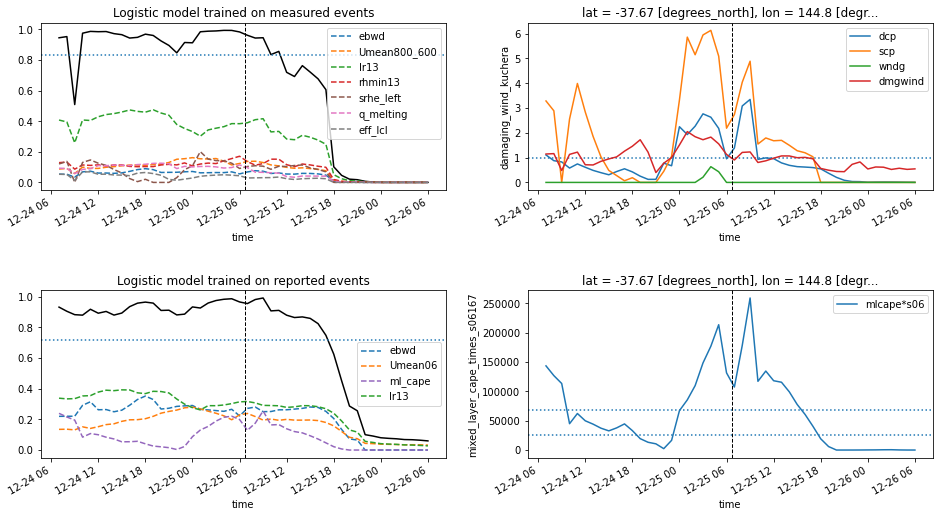

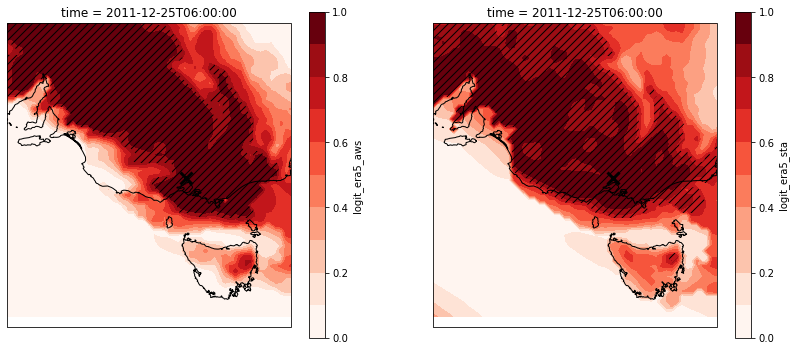

<Figure size 432x576 with 0 Axes>

In [4]:
title = "Melbourne supercell storm, 2011-12-25"
display(Markdown('<strong>{}</strong>'.format(title)))

lon = 144.8322; lat = -37.6654; time = [dt.datetime(2011,12,25,6,45)]; delta_t = 24; stn_id = 86282
f = xr.open_dataset("/g/data/eg3/ab4502/ExtremeWind/aus/era5/era5_20111201_20111231.nc")
f_point = f.sel({"time":slice(time[0] - dt.timedelta(hours=delta_t), time[0] + dt.timedelta(hours=delta_t))})\
        .interp({"lat":lat, "lon":lon}, method="nearest")

plt.figure(figsize=[16,8])
plt.subplot(2,2,1); plot_era5_aws_ts(f_point, time)
plt.subplot(2,2,3); plot_era5_sta_ts(f_point, time)
plt.subplot(2,2,2); plot_other_indices(f_point, ["dcp", "scp", "wndg", "dmgwind"], time)
plt.subplot(2,2,4); plot_other_indices(f_point, ["mlcape*s06"], time)
plt.subplots_adjust(hspace=0.6)

plt.figure(figsize=[14,6])
ax1 = plt.subplot(121, projection=ccrs.PlateCarree())    
plot_era5_aws_spatial(f, time[0], ax1, lat, lon)
ax2 = plt.subplot(122, projection=ccrs.PlateCarree())    
plot_era5_sta_spatial(f, time[0], ax2, lat, lon)

plt.figure(figsize=[6,8])
plot_sounding(time[0],lat,lon)

plt.figure(figsize=[14,6])
plt.subplot(121,projection=ccrs.PlateCarree())
plot_radar("02", time[0], lon, lat)
plt.subplot(122)
df=plot_aws_gust(time[0], delta_t, stn_id)

<strong>Cressy microburst, 2020-01-31</strong>

INFO: LOADING RADAR FILE FOR ID 02 AND TIME 20200131


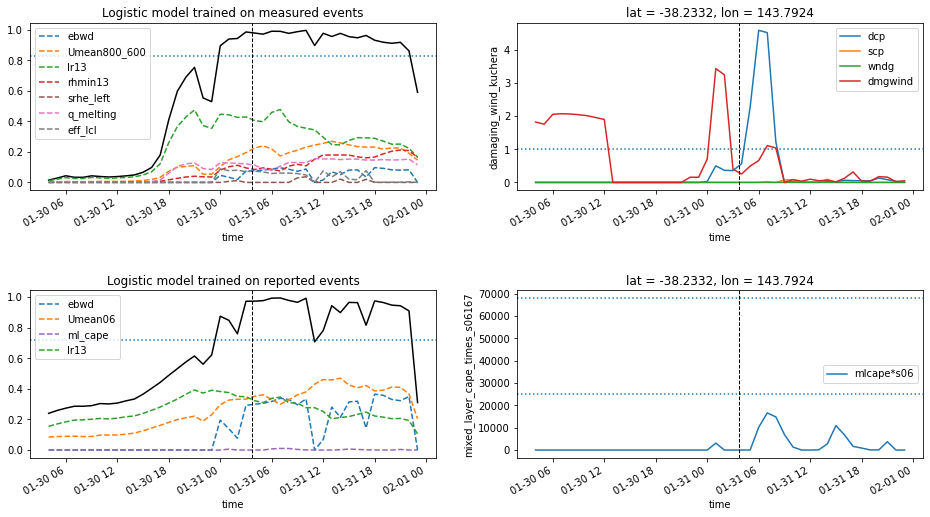

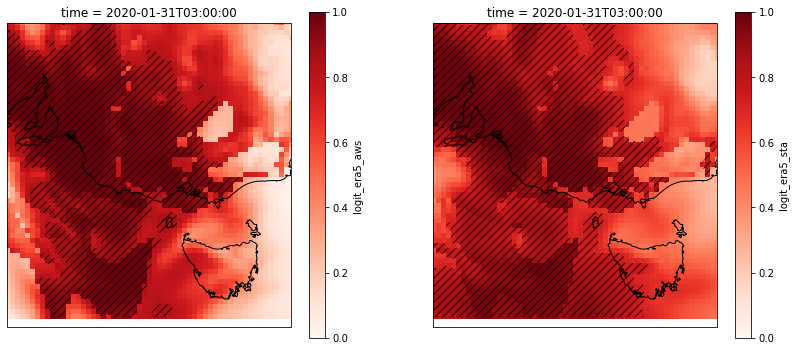

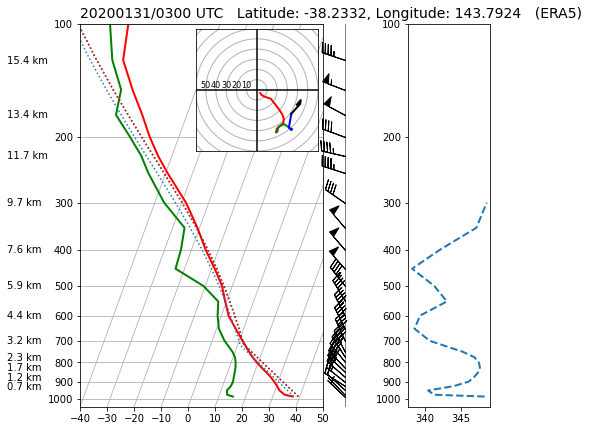

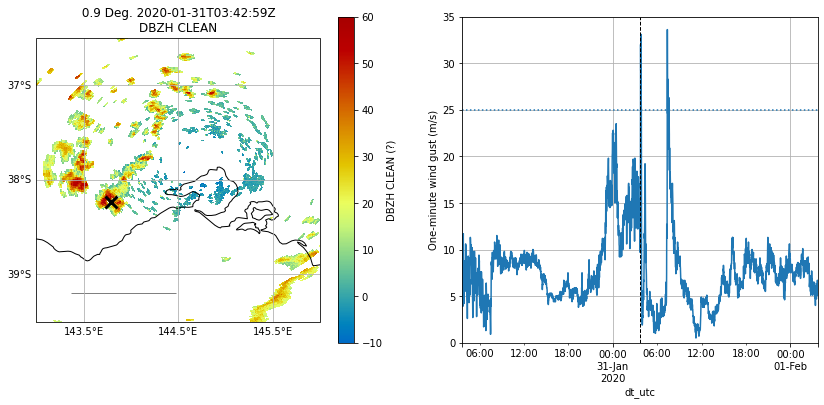

In [9]:
title = "Cressy microburst, 2020-01-31"
display(Markdown('<strong>{}</strong>'.format(title)))

lat = -38.2332; lon = 143.7924; time = [dt.datetime(2020,1,31,3,40)]; delta_t = 24; stn_id = 90035
f = xr.open_dataset("/g/data/eg3/ab4502/ExtremeWind/aus/era5/20200101_20200131.nc")
f_point = f.sel({"time":slice(time[0] - dt.timedelta(hours=delta_t), time[0] + dt.timedelta(hours=delta_t))})\
        .interp({"lat":lat, "lon":lon}, method="nearest")

plt.figure(figsize=[16,8])
plt.subplot(2,2,1); plot_era5_aws_ts(f_point, time)
plt.subplot(2,2,3); plot_era5_sta_ts(f_point, time)
plt.subplot(2,2,2); plot_other_indices(f_point, ["dcp", "scp", "wndg", "dmgwind"], time)
plt.subplot(2,2,4); plot_other_indices(f_point, ["mlcape*s06"], time)
plt.subplots_adjust(hspace=0.6)

plt.figure(figsize=[14,6])
ax1 = plt.subplot(121, projection=ccrs.PlateCarree())    
plot_era5_aws_spatial(f, time[0], ax1, lat, lon)
ax2 = plt.subplot(122, projection=ccrs.PlateCarree())    
plot_era5_sta_spatial(f, time[0], ax2, lat, lon)

plt.figure(figsize=[6,8])
plot_sounding(time[0],lat,lon)

plt.figure(figsize=[14,6])
plt.subplot(121,projection=ccrs.PlateCarree())
plot_radar("02", time[0], lon, lat)
plt.subplot(122)
df=plot_aws_gust(time[0], delta_t, stn_id)

<strong>Melbourne cool season squall line, 2009-08-02</strong>

INFO: LOADING RADAR FILE FOR ID 02 AND TIME 20090802


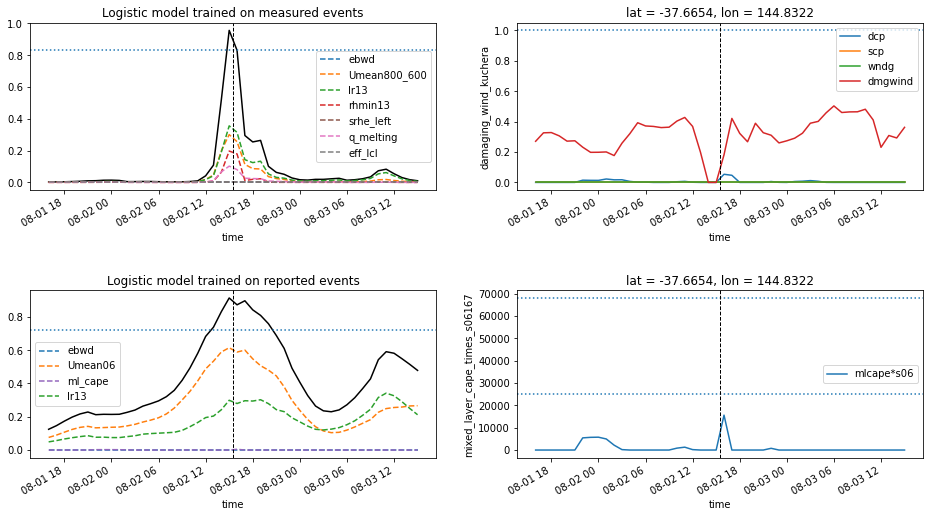

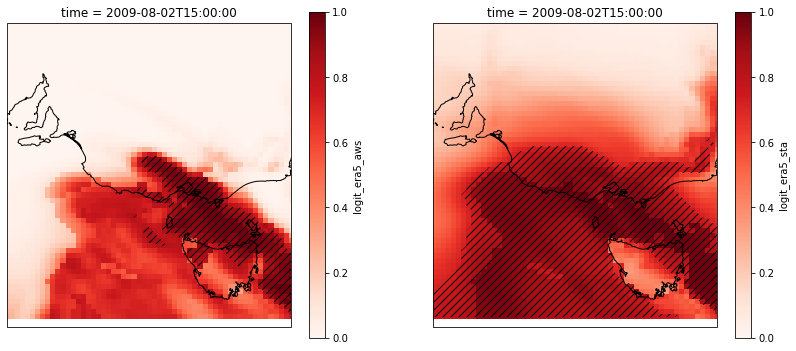

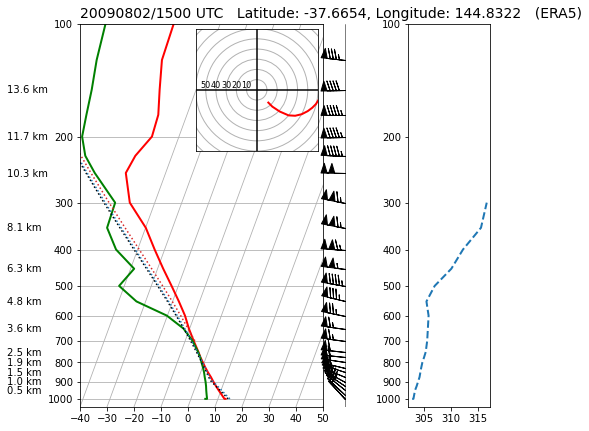

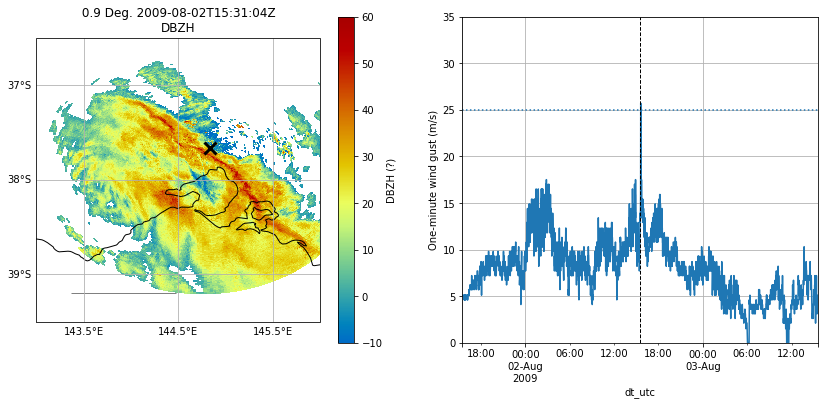

In [10]:
title = "Melbourne cool season squall line, 2009-08-02"
display(Markdown('<strong>{}</strong>'.format(title)))

lon = 144.8322; lat = -37.6654; time = [dt.datetime(2009,8,2,15,30)]; delta_t = 24; stn_id = 86282
f = xr.open_dataset("/g/data/eg3/ab4502/ExtremeWind/aus/era5/era5_20090801_20090831.nc")
f_point = f.sel({"time":slice(time[0] - dt.timedelta(hours=delta_t), time[0] + dt.timedelta(hours=delta_t))})\
        .interp({"lat":lat, "lon":lon}, method="nearest")

plt.figure(figsize=[16,8])
plt.subplot(2,2,1); plot_era5_aws_ts(f_point, time)
plt.subplot(2,2,3); plot_era5_sta_ts(f_point, time)
plt.subplot(2,2,2); plot_other_indices(f_point, ["dcp", "scp", "wndg", "dmgwind"], time)
plt.subplot(2,2,4); plot_other_indices(f_point, ["mlcape*s06"], time)
plt.subplots_adjust(hspace=0.6)

plt.figure(figsize=[14,6])
ax1 = plt.subplot(121, projection=ccrs.PlateCarree())    
plot_era5_aws_spatial(f, time[0], ax1, lat, lon)
ax2 = plt.subplot(122, projection=ccrs.PlateCarree())    
plot_era5_sta_spatial(f, time[0], ax2, lat, lon)

plt.figure(figsize=[6,8])
plot_sounding(time[0],lat,lon)

plt.figure(figsize=[14,6])
plt.subplot(121,projection=ccrs.PlateCarree())
plot_radar("02", time[0], lon, lat)
plt.subplot(122)
df=plot_aws_gust(time[0], delta_t, stn_id)

<strong>Melbourne warm season squall, 2015-02-26</strong>

46.1945631015483 0.0 27.379416195935722
INFO: LOADING RADAR FILE FOR ID 02 AND TIME 20150228


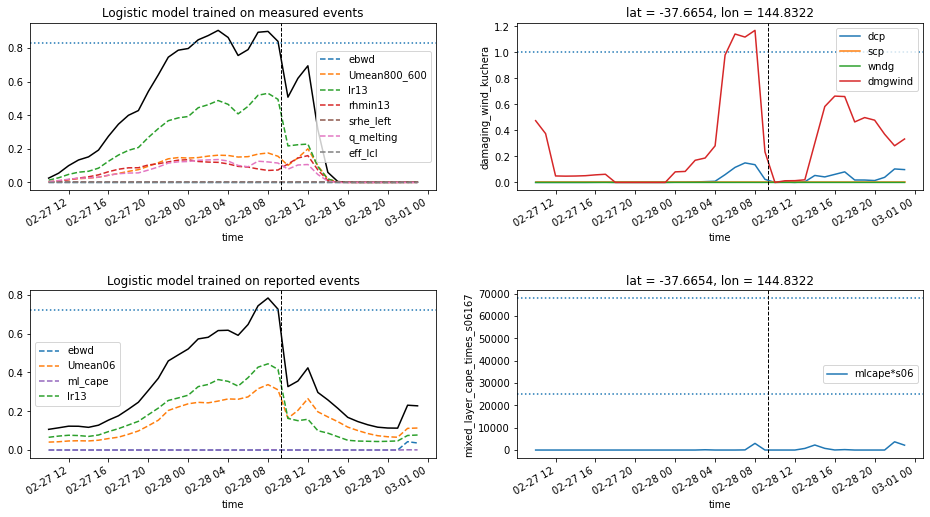

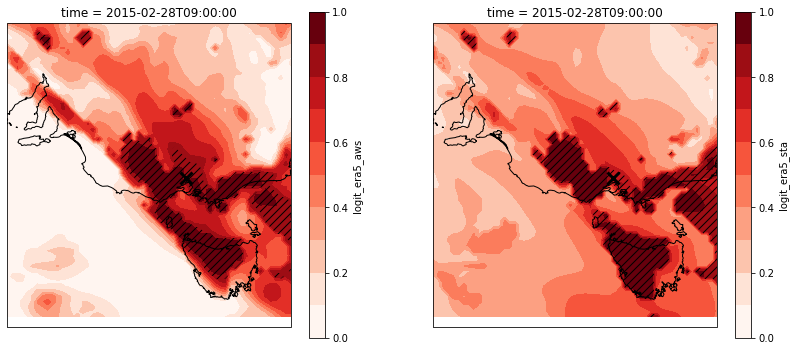

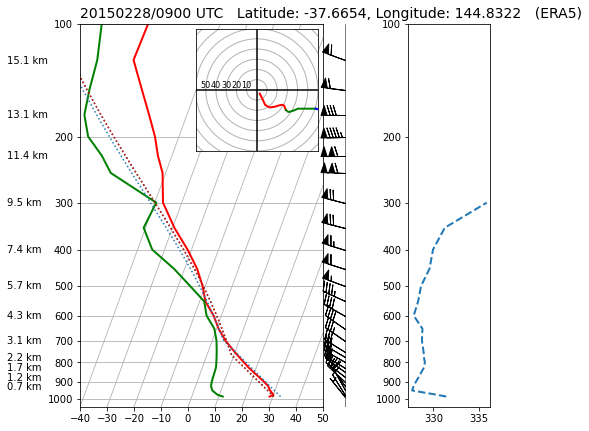

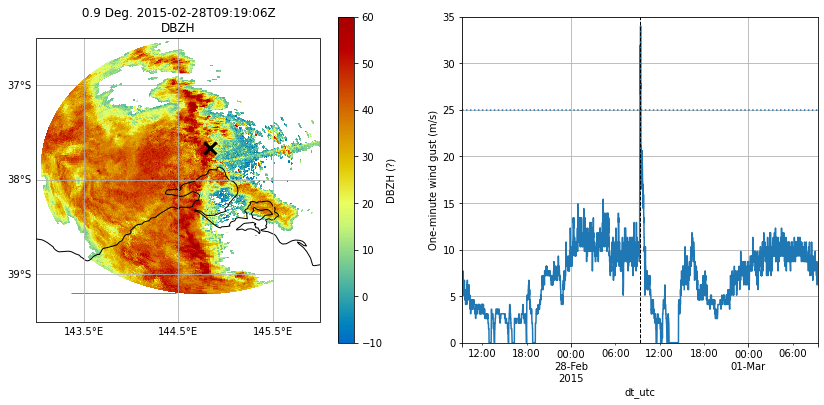

In [8]:
title = "Melbourne warm season squall, 2015-02-28"
display(Markdown('<strong>{}</strong>'.format(title)))

lon = 144.8322; lat = -37.6654; time = [dt.datetime(2015,2,28,9,20)]; delta_t = 24; stn_id = 86282
f = xr.open_dataset("/g/data/eg3/ab4502/ExtremeWind/aus/era5/era5_20150201_20150228.nc")
f_point = f.sel({"time":slice(time[0] - dt.timedelta(hours=delta_t), time[0] + dt.timedelta(hours=delta_t))})\
        .interp({"lat":lat, "lon":lon}, method="nearest")

plt.figure(figsize=[16,8])
plt.subplot(2,2,1); plot_era5_aws_ts(f_point, time)
plt.subplot(2,2,3); plot_era5_sta_ts(f_point, time)
plt.subplot(2,2,2); plot_other_indices(f_point, ["dcp", "scp", "wndg", "dmgwind"], time)
plt.subplot(2,2,4); plot_other_indices(f_point, ["mlcape*s06"], time)
plt.subplots_adjust(hspace=0.6)

plt.figure(figsize=[14,6])
ax1 = plt.subplot(121, projection=ccrs.PlateCarree())    
plot_era5_aws_spatial(f, time[0], ax1, lat, lon)
ax2 = plt.subplot(122, projection=ccrs.PlateCarree())    
plot_era5_sta_spatial(f, time[0], ax2, lat, lon)

plt.figure(figsize=[6,8])
plot_sounding(time[0],lat,lon)

plt.figure(figsize=[14,6])
plt.subplot(121,projection=ccrs.PlateCarree())
plot_radar("02", time[0], lon, lat)
plt.subplot(122)
df=plot_aws_gust(time[0], delta_t, stn_id)

In [7]:
title = "Melbourne cool season squall, 2020-08-27"
display(Markdown('<strong>{}</strong>'.format(title)))

lon = 144.4783; lat = -38.0288; time = [dt.datetime(2020,8,27,7,15)]; delta_t = 24; stn_id = 87113
f = xr.open_dataset("/g/data/eg3/ab4502/ExtremeWind/aus/era5/era5_20200801_20200831.nc")
f_point = f.sel({"time":slice(time[0] - dt.timedelta(hours=delta_t), time[0] + dt.timedelta(hours=delta_t))})\
        .interp({"lat":lat, "lon":lon}, method="nearest")

# plt.figure(figsize=[16,8])
# plt.subplot(2,2,1); plot_era5_aws_ts(f_point, time)
# plt.subplot(2,2,3); plot_era5_sta_ts(f_point, time)
# plt.subplot(2,2,2); plot_other_indices(f_point, ["dcp", "scp", "wndg", "dmgwind"], time)
# plt.subplot(2,2,4); plot_other_indices(f_point, ["mlcape*s06"], time)
# plt.subplots_adjust(hspace=0.6)

# plt.figure(figsize=[14,6])
# ax1 = plt.subplot(121, projection=ccrs.PlateCarree())    
# plot_era5_aws_spatial(f, time[0], ax1, lat, lon)
# ax2 = plt.subplot(122, projection=ccrs.PlateCarree())    
# plot_era5_sta_spatial(f, time[0], ax2, lat, lon)

plt.figure(figsize=[6,8])
plot_sounding(time[0],lat,lon)

# plt.figure(figsize=[14,6])
# plt.subplot(121,projection=ccrs.PlateCarree())
# plot_radar("2", time[0], lon, lat)
# plt.subplot(122)
# df=plot_aws_gust(time[0], delta_t, stn_id)

# ax=plt.axes(projection=ccrs.PlateCarree())
# radar = xr.open_dataset("/g/data/rq0/level_2/2/COLUMNMAXREFLECTIVITY/2_20200827_columnmaxreflectivity.nc")
# plt.pcolormesh(
#     radar.longitude,
#     radar.latitude,
#     radar.sel(time="2020-08-27 07:12").columnmaxreflectivity.squeeze(),
#     vmin=0,vmax=50,cmap=pyart.graph.cm_colorblind.HomeyerRainbow)
# ax.coastlines()
# ax.gridlines(draw_labels=["bottom","left"],ls=":")
# plt.colorbar()

# plt.figure()
# df=plot_aws_gust(time[0], 2, stn_id)

<strong>Melbourne cool season squall, 2020-08-27</strong>

34.08210216452251 30.056298490606075 38.978299762801846


AttributeError: 'NoneType' object has no attribute '_get_renderer'

<Figure size 600x800 with 4 Axes>

<strong>Ballarat squall line, 2020-05-19</strong>

INFO: LOADING RADAR FILE FOR ID 02 AND TIME 20200519


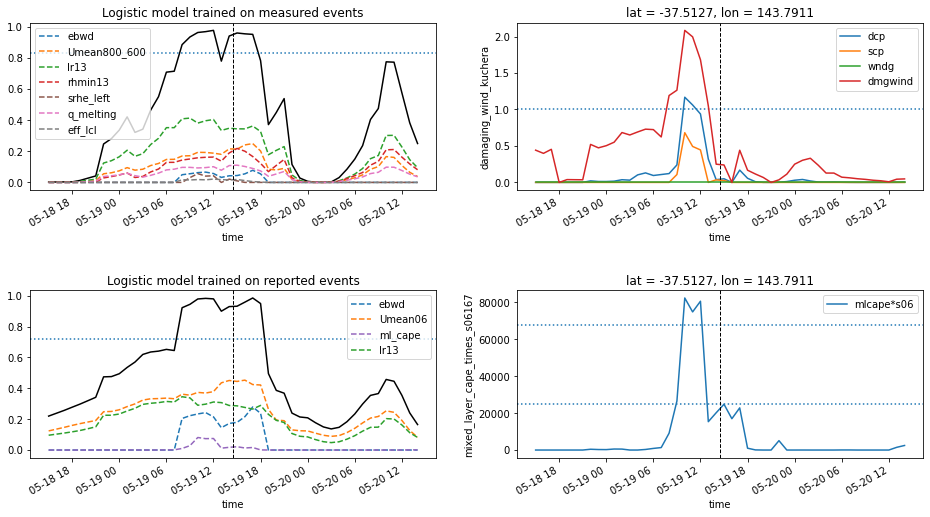

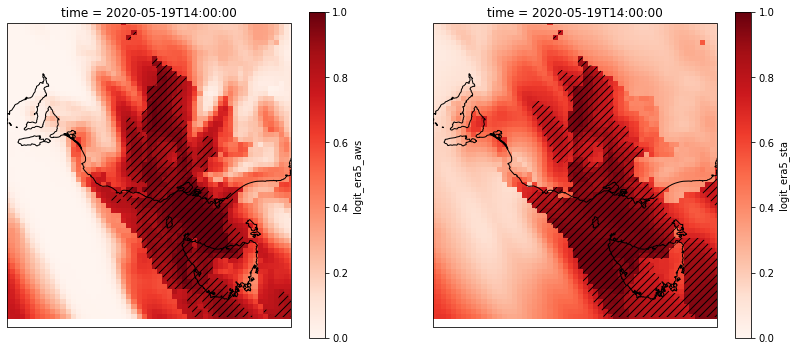

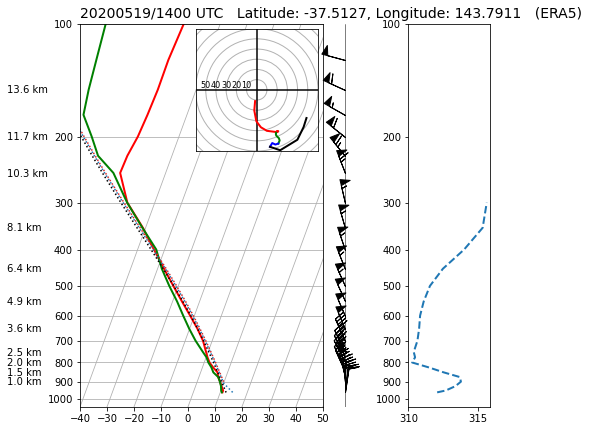

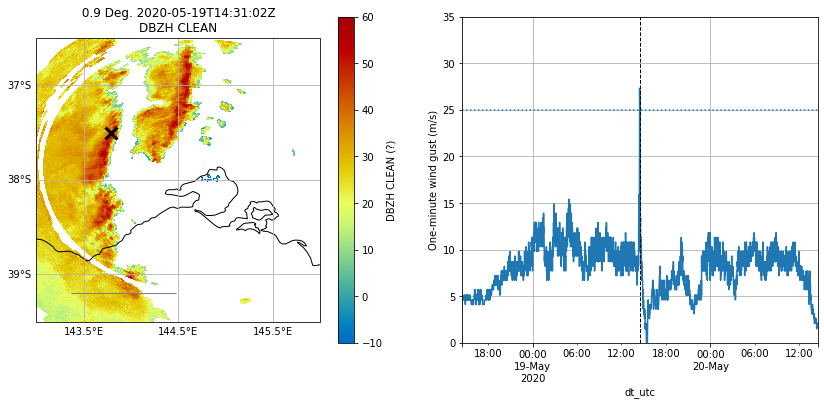

In [16]:
title = "Ballarat squall line, 2020-05-19"
display(Markdown('<strong>{}</strong>'.format(title)))

lon = 143.7911; lat = -37.5127; time = [dt.datetime(2020,5,19,14,30)]; delta_t = 24; stn_id = 89002
f = xr.open_dataset("/g/data/eg3/ab4502/ExtremeWind/aus/era5/era5_20200501_20200531.nc")
f_point = f.sel({"time":slice(time[0] - dt.timedelta(hours=delta_t), time[0] + dt.timedelta(hours=delta_t))})\
        .interp({"lat":lat, "lon":lon}, method="nearest")

plt.figure(figsize=[16,8])
plt.subplot(2,2,1); plot_era5_aws_ts(f_point, time)
plt.subplot(2,2,3); plot_era5_sta_ts(f_point, time)
plt.subplot(2,2,2); plot_other_indices(f_point, ["dcp", "scp", "wndg", "dmgwind"], time)
plt.subplot(2,2,4); plot_other_indices(f_point, ["mlcape*s06"], time)
plt.subplots_adjust(hspace=0.6)

plt.figure(figsize=[14,6])
ax1 = plt.subplot(121, projection=ccrs.PlateCarree())    
plot_era5_aws_spatial(f, time[0], ax1, lat, lon)
ax2 = plt.subplot(122, projection=ccrs.PlateCarree())    
plot_era5_sta_spatial(f, time[0], ax2, lat, lon)

plt.figure(figsize=[6,8])
plot_sounding(time[0],lat,lon)

plt.figure(figsize=[14,6])
plt.subplot(121,projection=ccrs.PlateCarree())
plot_radar("02", time[0], lon, lat)
plt.subplot(122)
df=plot_aws_gust(time[0], delta_t, stn_id)

<strong>Dandenong, 2021-06-09</strong>

INFO: LOADING RADAR FILE FOR ID 02 AND TIME 20210609


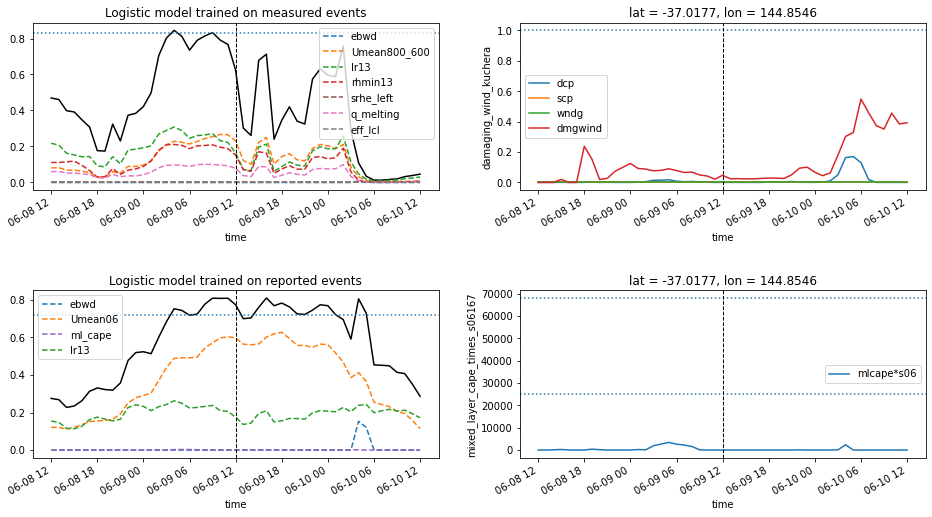

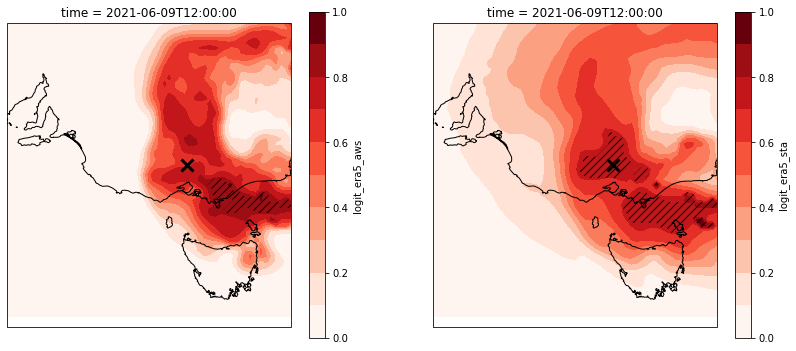

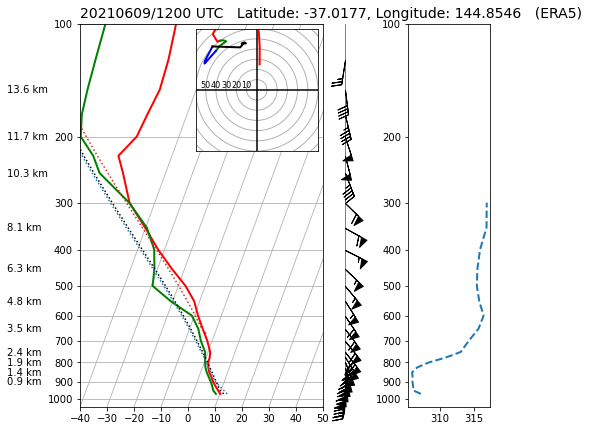

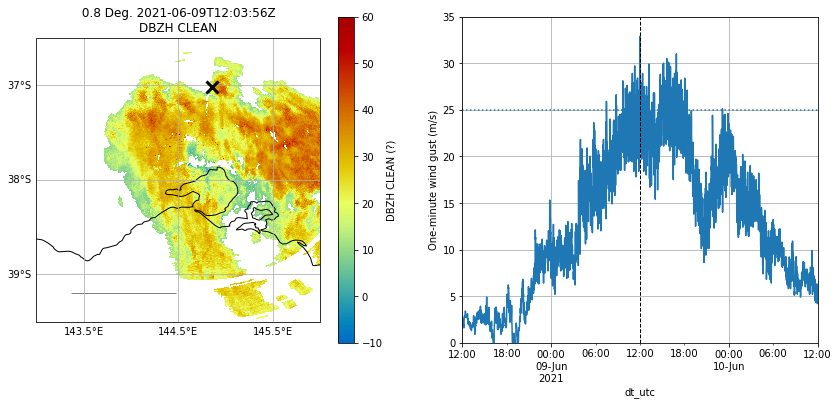

In [47]:
title = "Dandenong, 2021-06-09"
display(Markdown('<strong>{}</strong>'.format(title)))

stn_id=88166; lat=-37.0177; lon=144.8546; time = [dt.datetime(2021,6,9,12,0)]; delta_t = 24;
f = xr.open_dataset("/g/data/eg3/ab4502/ExtremeWind/aus/era5/dandenong_20210608_20210610.nc")
f_point = f.sel({"time":slice(time[0] - dt.timedelta(hours=delta_t), time[0] + dt.timedelta(hours=delta_t))})\
        .interp({"lat":lat, "lon":lon}, method="nearest")

plt.figure(figsize=[16,8])
plt.subplot(2,2,1); plot_era5_aws_ts(f_point, time)
plt.subplot(2,2,3); plot_era5_sta_ts(f_point, time)
plt.subplot(2,2,2); plot_other_indices(f_point, ["dcp", "scp", "wndg", "dmgwind"], time)
plt.subplot(2,2,4); plot_other_indices(f_point, ["mlcape*s06"], time)
plt.subplots_adjust(hspace=0.6)

plt.figure(figsize=[14,6])
ax1 = plt.subplot(121, projection=ccrs.PlateCarree())    
plot_era5_aws_spatial(f, time[0], ax1, lat, lon)
ax2 = plt.subplot(122, projection=ccrs.PlateCarree())    
plot_era5_sta_spatial(f, time[0], ax2, lat, lon)

plt.figure(figsize=[6,8])
plot_sounding(time[0],lat,lon,cds=True,cds_pres_fname="/g/data/eg3/ab4502/era5_download/dandenong_pl.nc",
              cds_sfc_fname="/g/data/eg3/ab4502/era5_download/dandenong_sfc.nc")

plt.figure(figsize=[14,6])
plt.subplot(121,projection=ccrs.PlateCarree())
plot_radar("02", time[0], lon, lat, sweep=12)
plt.subplot(122)
df=plot_aws_gust(time[0], delta_t, stn_id)

<strong>ETSA squall line, 2016-11-21</strong>

INFO: UNPACKING RADAR FILE FOR ID 02 AND TIME 20161121


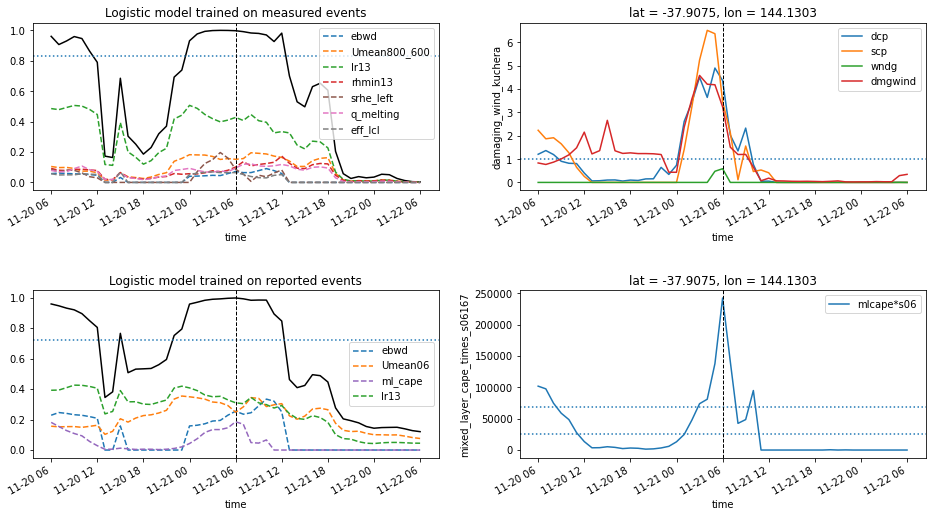

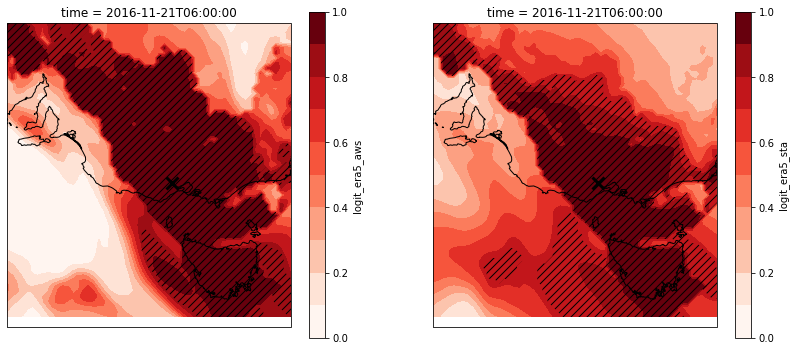

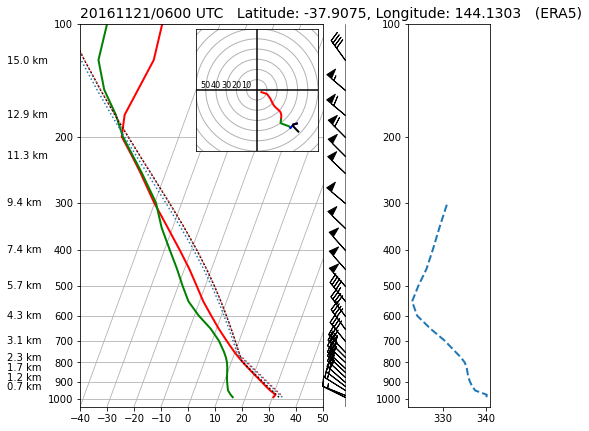

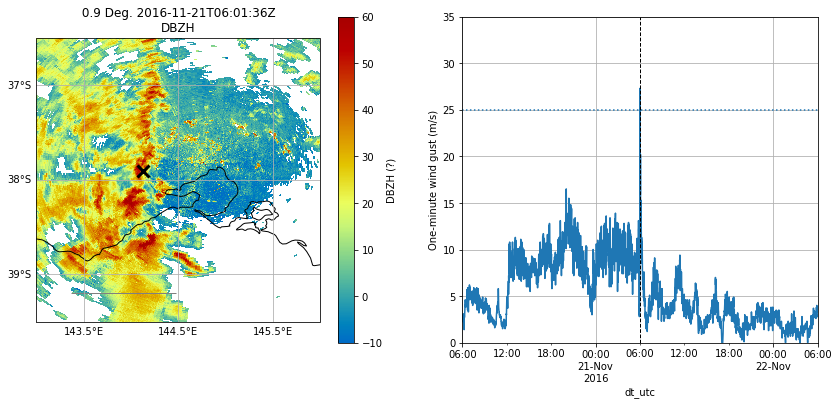

In [53]:
title = "ETSA squall line, 2016-11-21"
display(Markdown('<strong>{}</strong>'.format(title)))

stn_id=87168; lat=-37.9075; lon=144.1303; time = [dt.datetime(2016,11,21,6,0)]; delta_t = 24;
f = xr.open_dataset("/g/data/eg3/ab4502/ExtremeWind/aus/era5/era5_20161101_20161130.nc")
f_point = f.sel({"time":slice(time[0] - dt.timedelta(hours=delta_t), time[0] + dt.timedelta(hours=delta_t))})\
        .interp({"lat":lat, "lon":lon}, method="nearest")

plt.figure(figsize=[16,8])
plt.subplot(2,2,1); plot_era5_aws_ts(f_point, time)
plt.subplot(2,2,3); plot_era5_sta_ts(f_point, time)
plt.subplot(2,2,2); plot_other_indices(f_point, ["dcp", "scp", "wndg", "dmgwind"], time)
plt.subplot(2,2,4); plot_other_indices(f_point, ["mlcape*s06"], time)
plt.subplots_adjust(hspace=0.6)

plt.figure(figsize=[14,6])
ax1 = plt.subplot(121, projection=ccrs.PlateCarree())    
plot_era5_aws_spatial(f, time[0], ax1, lat, lon)
ax2 = plt.subplot(122, projection=ccrs.PlateCarree())    
plot_era5_sta_spatial(f, time[0], ax2, lat, lon)

plt.figure(figsize=[6,8])
plot_sounding(time[0],lat,lon)

plt.figure(figsize=[14,6])
plt.subplot(121,projection=ccrs.PlateCarree())
plot_radar("02", time[0], lon, lat)
plt.subplot(122)
df=plot_aws_gust(time[0], delta_t, stn_id)

<strong>Severe thunderstorm, 2010-03-06</strong>

INFO: UNPACKING RADAR FILE FOR ID 02 AND TIME 20100306


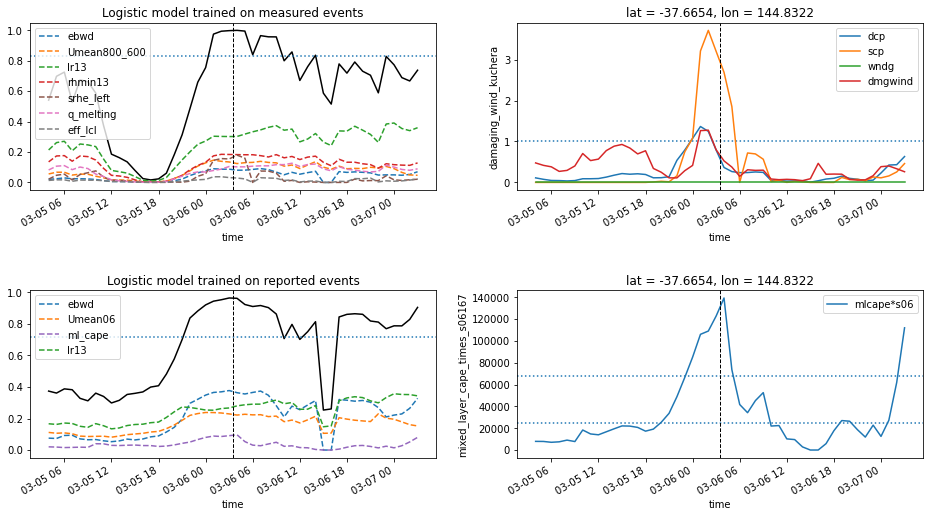

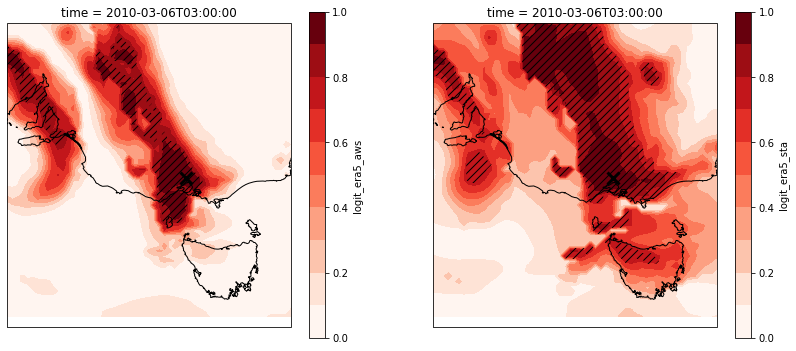

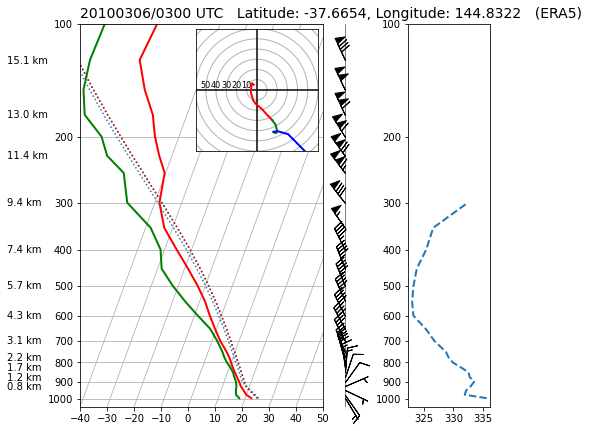

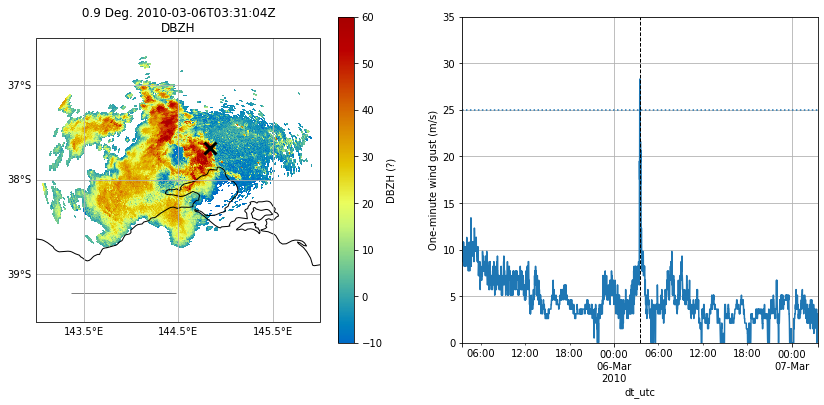

In [12]:
title = "Severe thunderstorm, 2010-03-06"
display(Markdown('<strong>{}</strong>'.format(title)))

stn_id=86282; lat=-37.6654; lon=144.8322; time = [dt.datetime(2010,3,6,3,30)]; delta_t = 24;
f = xr.open_dataset("/g/data/eg3/ab4502/ExtremeWind/aus/era5/era5_20100301_20100331.nc")
f_point = f.sel({"time":slice(time[0] - dt.timedelta(hours=delta_t), time[0] + dt.timedelta(hours=delta_t))})\
        .interp({"lat":lat, "lon":lon}, method="nearest")

plt.figure(figsize=[16,8])
plt.subplot(2,2,1); plot_era5_aws_ts(f_point, time)
plt.subplot(2,2,3); plot_era5_sta_ts(f_point, time)
plt.subplot(2,2,2); plot_other_indices(f_point, ["dcp", "scp", "wndg", "dmgwind"], time)
plt.subplot(2,2,4); plot_other_indices(f_point, ["mlcape*s06"], time)
plt.subplots_adjust(hspace=0.6)

plt.figure(figsize=[14,6])
ax1 = plt.subplot(121, projection=ccrs.PlateCarree())    
plot_era5_aws_spatial(f, time[0], ax1, lat, lon)
ax2 = plt.subplot(122, projection=ccrs.PlateCarree())    
plot_era5_sta_spatial(f, time[0], ax2, lat, lon)

plt.figure(figsize=[6,8])
plot_sounding(time[0],lat,lon)

plt.figure(figsize=[14,6])
plt.subplot(121,projection=ccrs.PlateCarree())
plot_radar("02", time[0], lon, lat)
plt.subplot(122)
df=plot_aws_gust(time[0], delta_t, stn_id)

<strong>Boorowa squall line 2020-12-01</strong>

INFO: LOADING RADAR FILE FOR ID 40 AND TIME 20201201


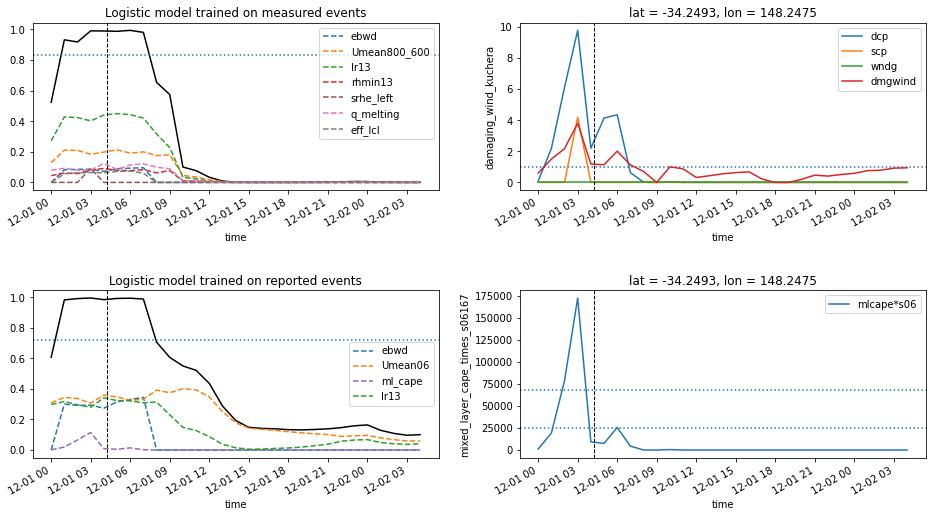

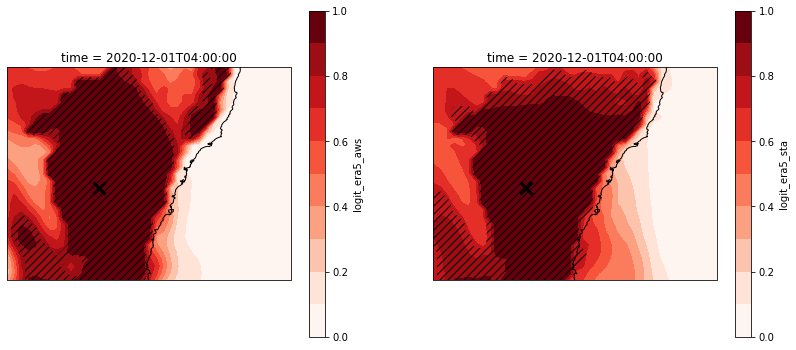

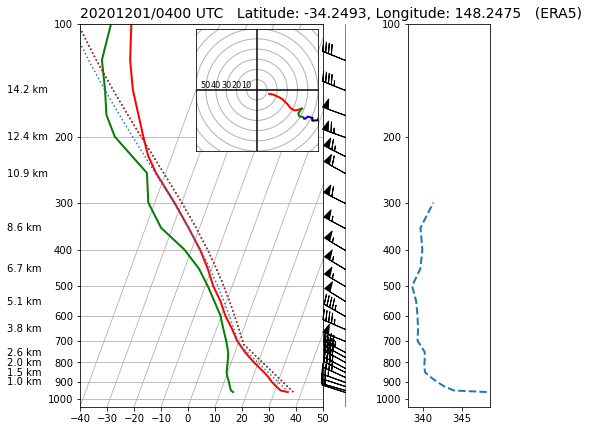

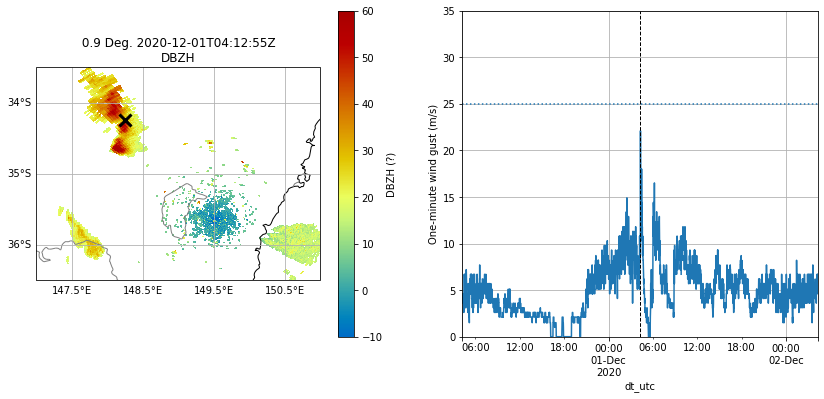

In [18]:
title = "Boorowa squall line 2020-12-01"
display(Markdown('<strong>{}</strong>'.format(title)))

stn_id=73138; lat=-34.2493; lon=148.2475; time = [dt.datetime(2020,12,1,4,15)]; delta_t = 24;
f = xr.open_dataset("/g/data/eg3/ab4502/ExtremeWind/aus/era5/era5_20201201_20201231.nc")
f_point = f.sel({"time":slice(time[0] - dt.timedelta(hours=delta_t), time[0] + dt.timedelta(hours=delta_t))})\
        .interp({"lat":lat, "lon":lon}, method="nearest")

plt.figure(figsize=[16,8])
plt.subplot(2,2,1); plot_era5_aws_ts(f_point, time)
plt.subplot(2,2,3); plot_era5_sta_ts(f_point, time)
plt.subplot(2,2,2); plot_other_indices(f_point, ["dcp", "scp", "wndg", "dmgwind"], time)
plt.subplot(2,2,4); plot_other_indices(f_point, ["mlcape*s06"], time)
plt.subplots_adjust(hspace=0.6)

plt.figure(figsize=[14,6])
ax1 = plt.subplot(121, projection=ccrs.PlateCarree())    
plot_era5_aws_spatial(f, time[0], ax1, lat, lon, domain="Sydney")
ax2 = plt.subplot(122, projection=ccrs.PlateCarree())    
plot_era5_sta_spatial(f, time[0], ax2, lat, lon, domain="Sydney")

plt.figure(figsize=[6,8])
plot_sounding(time[0],lat,lon)

plt.figure(figsize=[14,6])
plt.subplot(121,projection=ccrs.PlateCarree())
plot_radar("40", time[0], lon, lat)
plt.subplot(122)
df=plot_aws_gust(time[0], delta_t, stn_id, state="nsw")

<strong>Sydney severe thunderstorm 2016-01-14</strong>

INFO: LOADING RADAR FILE FOR ID 71 AND TIME 20160114


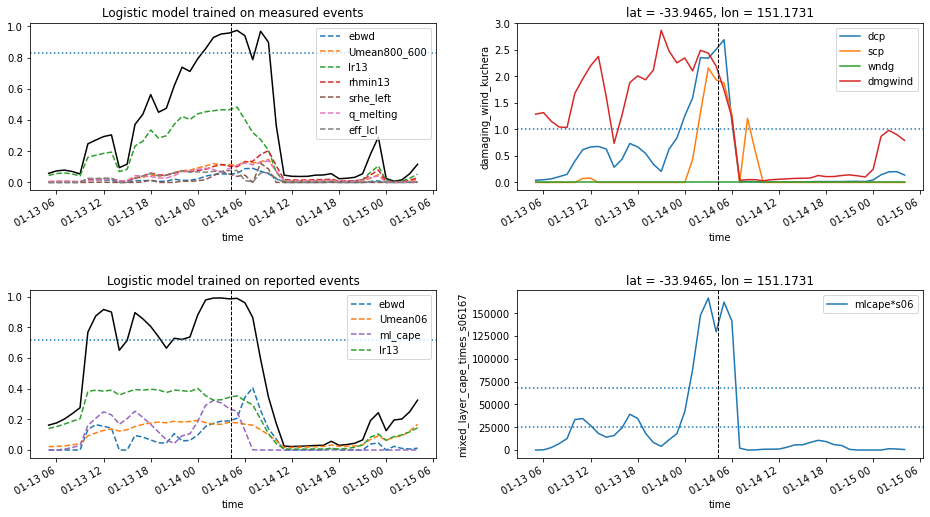

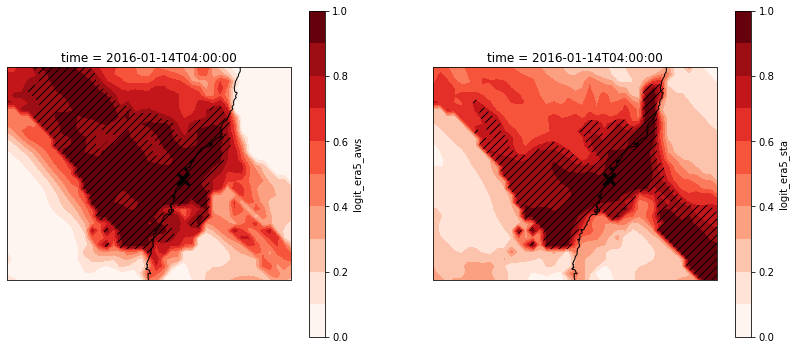

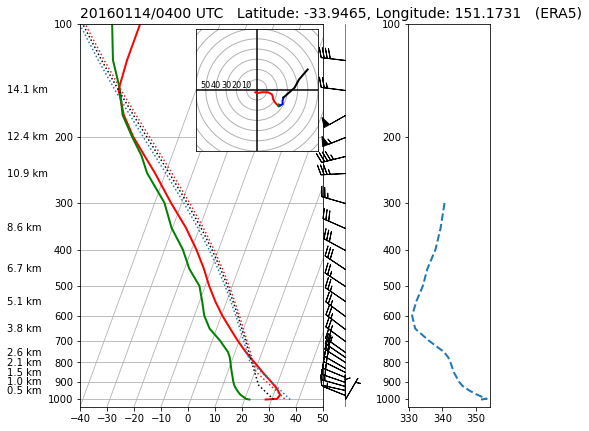

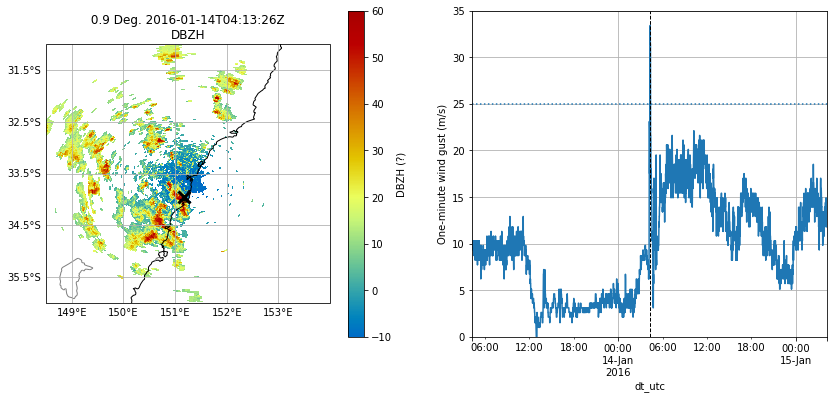

In [21]:
title = "Sydney severe thunderstorm 2016-01-14"
display(Markdown('<strong>{}</strong>'.format(title)))

stn_id=66037; lat=-33.9465; lon=151.1731; time = [dt.datetime(2016,1,14,4,15)]; delta_t = 24;
f = xr.open_dataset("/g/data/eg3/ab4502/ExtremeWind/aus/era5/era5_20160101_20160131.nc")
f_point = f.sel({"time":slice(time[0] - dt.timedelta(hours=delta_t), time[0] + dt.timedelta(hours=delta_t))})\
        .interp({"lat":lat, "lon":lon}, method="nearest")

plt.figure(figsize=[16,8])
plt.subplot(2,2,1); plot_era5_aws_ts(f_point, time)
plt.subplot(2,2,3); plot_era5_sta_ts(f_point, time)
plt.subplot(2,2,2); plot_other_indices(f_point, ["dcp", "scp", "wndg", "dmgwind"], time)
plt.subplot(2,2,4); plot_other_indices(f_point, ["mlcape*s06"], time)
plt.subplots_adjust(hspace=0.6)

plt.figure(figsize=[14,6])
ax1 = plt.subplot(121, projection=ccrs.PlateCarree())    
plot_era5_aws_spatial(f, time[0], ax1, lat, lon, domain="Sydney")
ax2 = plt.subplot(122, projection=ccrs.PlateCarree())    
plot_era5_sta_spatial(f, time[0], ax2, lat, lon, domain="Sydney")

plt.figure(figsize=[6,8])
plot_sounding(time[0],lat,lon)

plt.figure(figsize=[14,6])
plt.subplot(121,projection=ccrs.PlateCarree())
plot_radar("71", time[0], lon, lat)
plt.subplot(122)
df=plot_aws_gust(time[0], delta_t, stn_id, state="nsw")

<strong>Winton downburst 2016-11-11</strong>

1061.0260364746982 196.42601816985265 12.639787468448606
INFO: LOADING RADAR FILE FOR ID 56 AND TIME 20161111


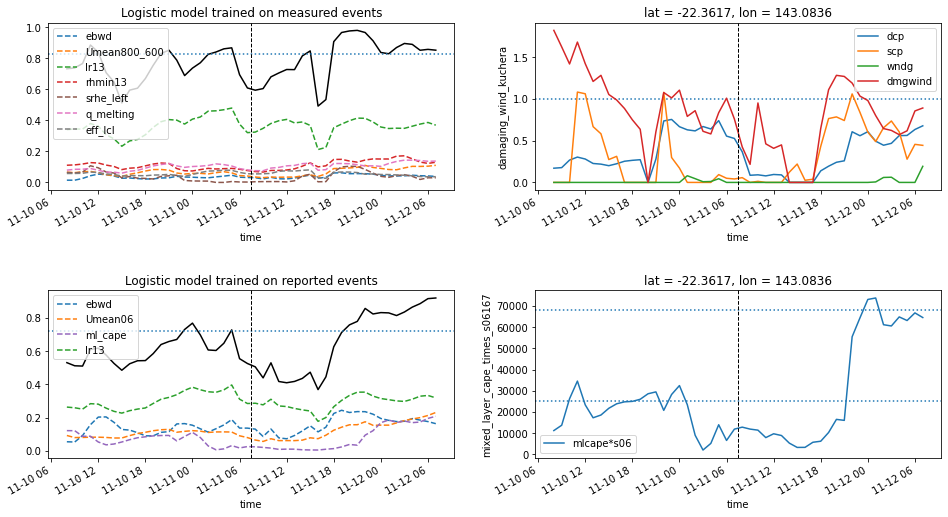

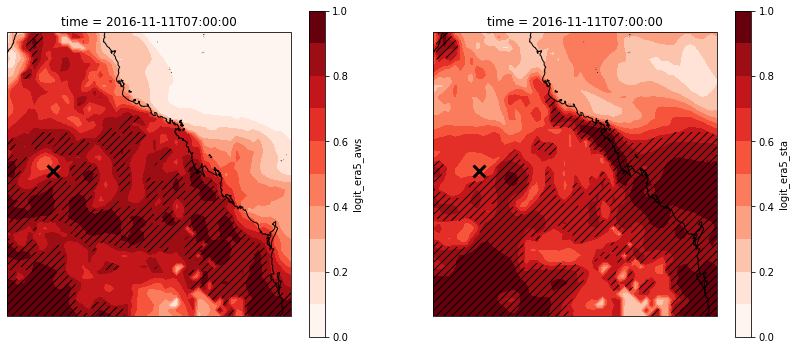

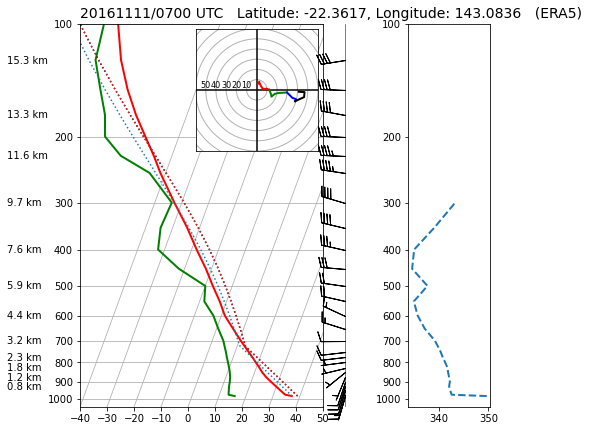

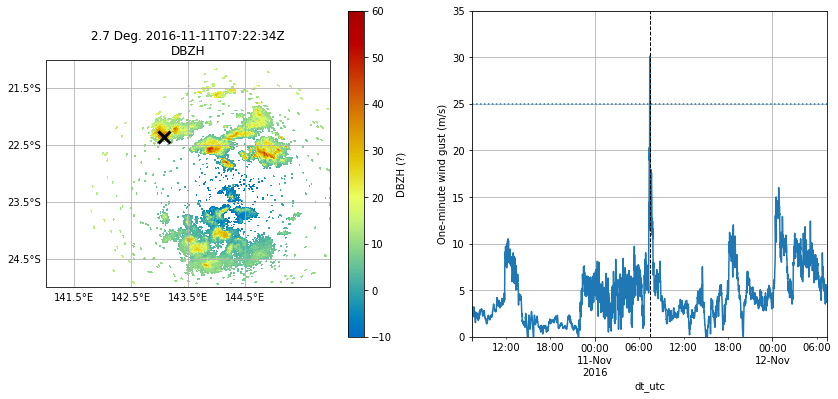

In [9]:
title = "Winton downburst 2016-11-11"
display(Markdown('<strong>{}</strong>'.format(title)))

stn_id=37039; lat=-22.3617; lon=143.0836; time = [dt.datetime(2016,11,11,7,25)]; delta_t = 24;
f = xr.open_dataset("/g/data/eg3/ab4502/ExtremeWind/aus/era5/era5_20161101_20161130.nc")
f_point = f.sel({"time":slice(time[0] - dt.timedelta(hours=delta_t), time[0] + dt.timedelta(hours=delta_t))})\
        .interp({"lat":lat, "lon":lon}, method="nearest")

plt.figure(figsize=[16,8])
plt.subplot(2,2,1); plot_era5_aws_ts(f_point, time)
plt.subplot(2,2,3); plot_era5_sta_ts(f_point, time)
plt.subplot(2,2,2); plot_other_indices(f_point, ["dcp", "scp", "wndg", "dmgwind"], time)
plt.subplot(2,2,4); plot_other_indices(f_point, ["mlcape*s06"], time)
plt.subplots_adjust(hspace=0.6)

plt.figure(figsize=[14,6])
ax1 = plt.subplot(121, projection=ccrs.PlateCarree())    
plot_era5_aws_spatial(f, time[0], ax1, lat, lon, domain="Brisbane")
ax2 = plt.subplot(122, projection=ccrs.PlateCarree())    
plot_era5_sta_spatial(f, time[0], ax2, lat, lon, domain="Brisbane")

plt.figure(figsize=[6,8])
plot_sounding(time[0],lat,lon)

plt.figure(figsize=[14,6])
plt.subplot(121,projection=ccrs.PlateCarree())
plot_radar("56", time[0], lon, lat, sweep=0)
plt.subplot(122)
df=plot_aws_gust(time[0], delta_t, stn_id, state="qld")

<strong>Double Island Point 2006-12-16</strong>

1359.0309670256229 1070.9679944816749 16.241038123952748
INFO: LOADING RADAR FILE FOR ID 08 AND TIME 20061216


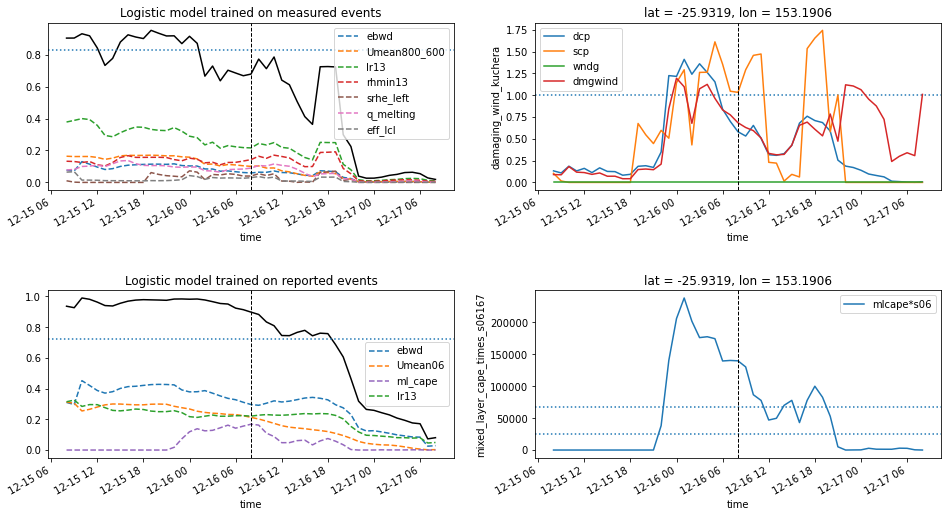

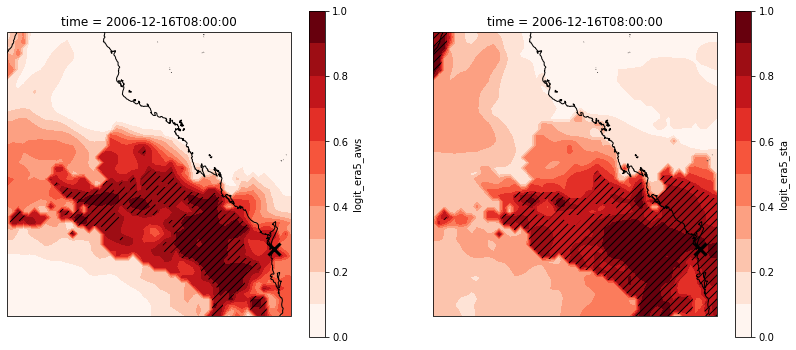

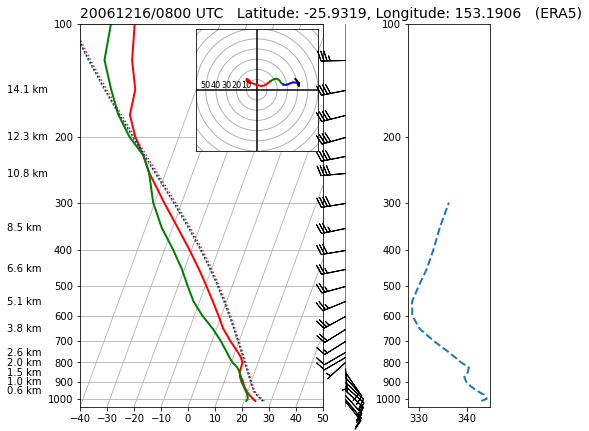

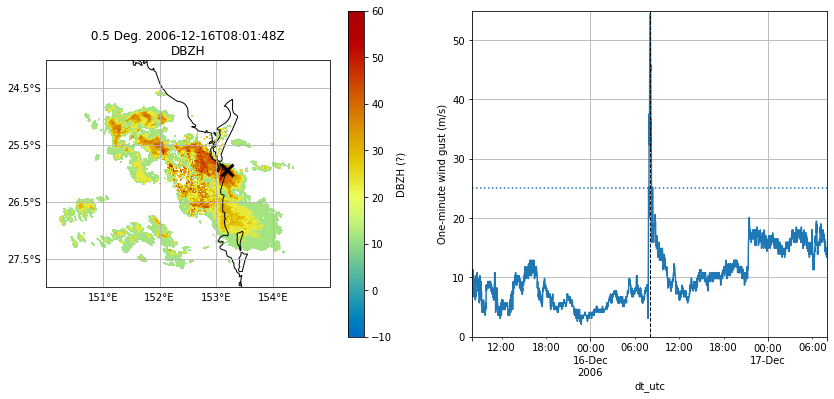

In [8]:
title = "Double Island Point 2006-12-16"
display(Markdown('<strong>{}</strong>'.format(title)))

stn_id=40068; lat=-25.9319; lon=153.1906; time = [dt.datetime(2006,12,16,8,0)]; delta_t = 24;
f = xr.open_dataset("/g/data/eg3/ab4502/ExtremeWind/aus/era5/era5_20061201_20061231.nc")
f_point = f.sel({"time":slice(time[0] - dt.timedelta(hours=delta_t), time[0] + dt.timedelta(hours=delta_t))})\
        .interp({"lat":lat, "lon":lon}, method="nearest")

plt.figure(figsize=[16,8])
plt.subplot(2,2,1); plot_era5_aws_ts(f_point, time)
plt.subplot(2,2,3); plot_era5_sta_ts(f_point, time)
plt.subplot(2,2,2); plot_other_indices(f_point, ["dcp", "scp", "wndg", "dmgwind"], time)
plt.subplot(2,2,4); plot_other_indices(f_point, ["mlcape*s06"], time)
plt.subplots_adjust(hspace=0.6)

plt.figure(figsize=[14,6])
ax1 = plt.subplot(121, projection=ccrs.PlateCarree())    
plot_era5_aws_spatial(f, time[0], ax1, lat, lon, domain="Brisbane")
ax2 = plt.subplot(122, projection=ccrs.PlateCarree())    
plot_era5_sta_spatial(f, time[0], ax2, lat, lon, domain="Brisbane")

plt.figure(figsize=[6,8])
plot_sounding(time[0],lat,lon)

plt.figure(figsize=[14,6])
plt.subplot(121,projection=ccrs.PlateCarree())
plot_radar("08", time[0], lon, lat, sweep=0)
plt.subplot(122)
df=plot_aws_gust(time[0], delta_t, stn_id, state="qld", vmax=55)

<strong>The Gap 2008-12-16</strong>

INFO: LOADING RADAR FILE FOR ID 50 AND TIME 20081116


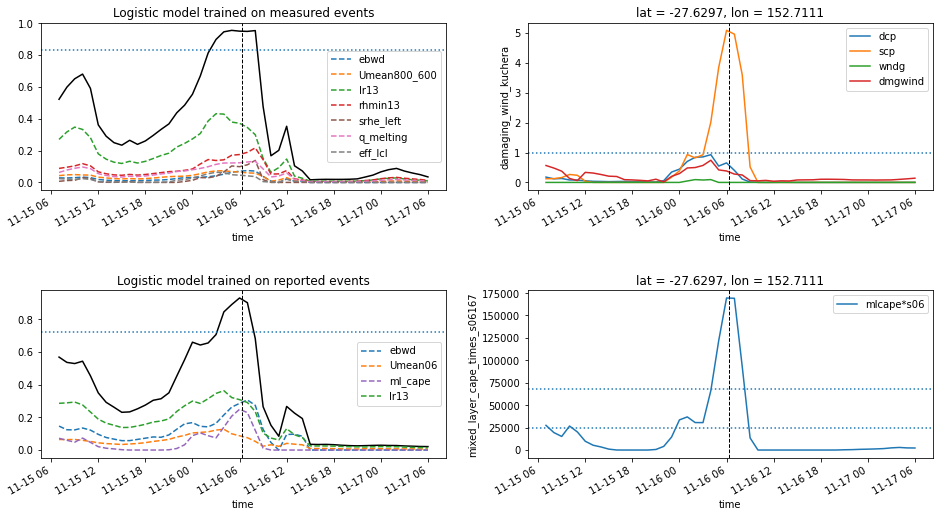

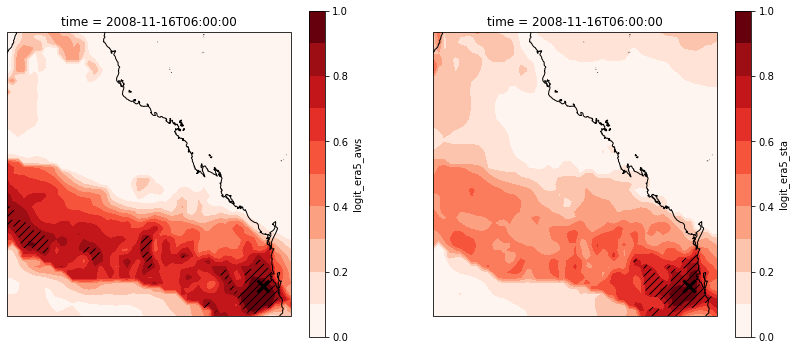

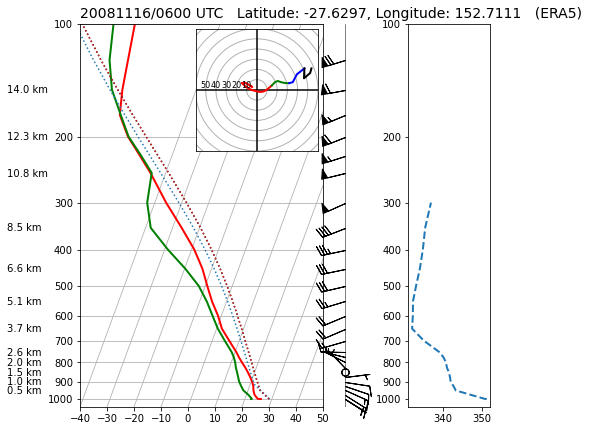

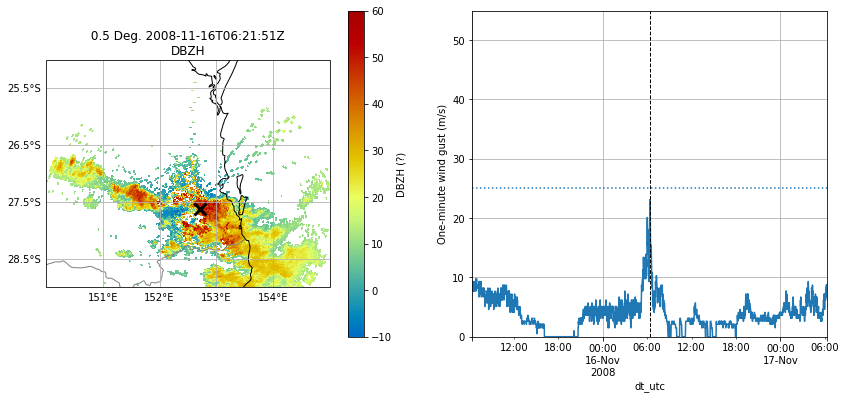

In [51]:
title = "The Gap 2008-12-16"
display(Markdown('<strong>{}</strong>'.format(title)))

stn_id=40004; lat=-27.6297; lon=152.7111; time = [dt.datetime(2008,11,16,6,20)]; delta_t = 24;
f = xr.open_dataset("/g/data/eg3/ab4502/ExtremeWind/aus/era5/era5_20081101_20081130.nc")
f_point = f.sel({"time":slice(time[0] - dt.timedelta(hours=delta_t), time[0] + dt.timedelta(hours=delta_t))})\
        .interp({"lat":lat, "lon":lon}, method="nearest")

plt.figure(figsize=[16,8])
plt.subplot(2,2,1); plot_era5_aws_ts(f_point, time)
plt.subplot(2,2,3); plot_era5_sta_ts(f_point, time)
plt.subplot(2,2,2); plot_other_indices(f_point, ["dcp", "scp", "wndg", "dmgwind"], time)
plt.subplot(2,2,4); plot_other_indices(f_point, ["mlcape*s06"], time)
plt.subplots_adjust(hspace=0.6)

plt.figure(figsize=[14,6])
ax1 = plt.subplot(121, projection=ccrs.PlateCarree())    
plot_era5_aws_spatial(f, time[0], ax1, lat, lon, domain="Brisbane")
ax2 = plt.subplot(122, projection=ccrs.PlateCarree())    
plot_era5_sta_spatial(f, time[0], ax2, lat, lon, domain="Brisbane")

plt.figure(figsize=[6,8])
plot_sounding(time[0],lat,lon)

plt.figure(figsize=[14,6])
plt.subplot(121,projection=ccrs.PlateCarree())
plot_radar("50", time[0], lon, lat, sweep=0)
plt.subplot(122)
df=plot_aws_gust(time[0], delta_t, stn_id, state="qld", vmax=35)

<strong>Oakey 2011-10-07</strong>

INFO: LOADING RADAR FILE FOR ID 50 AND TIME 20111007


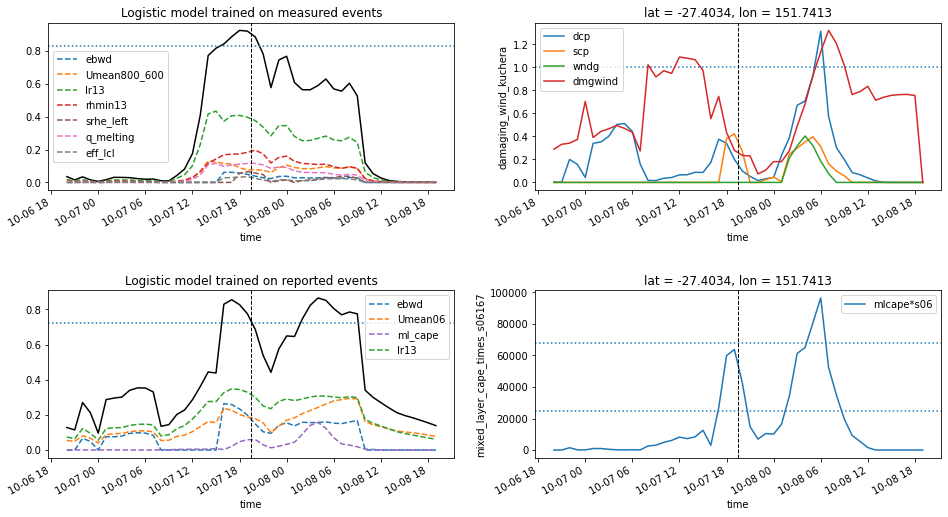

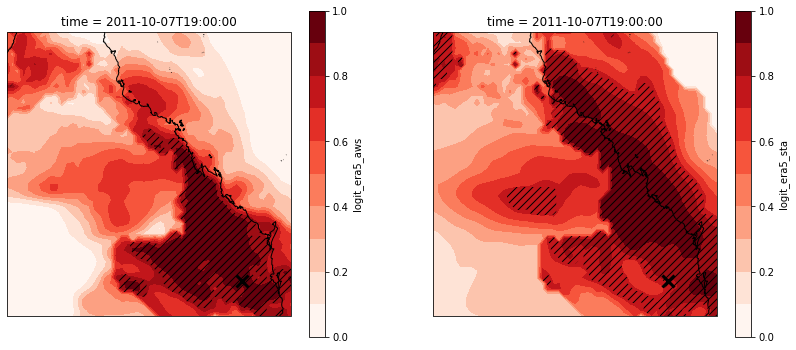

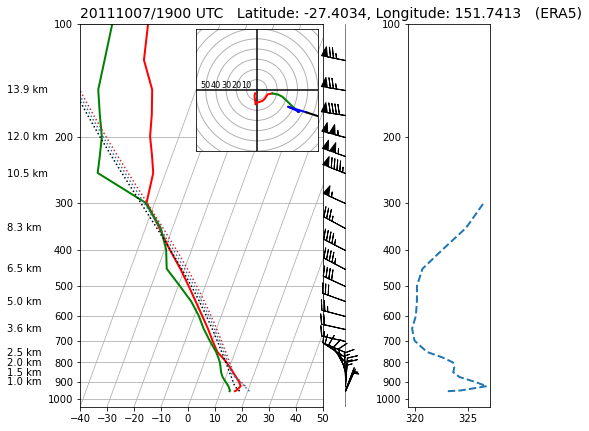

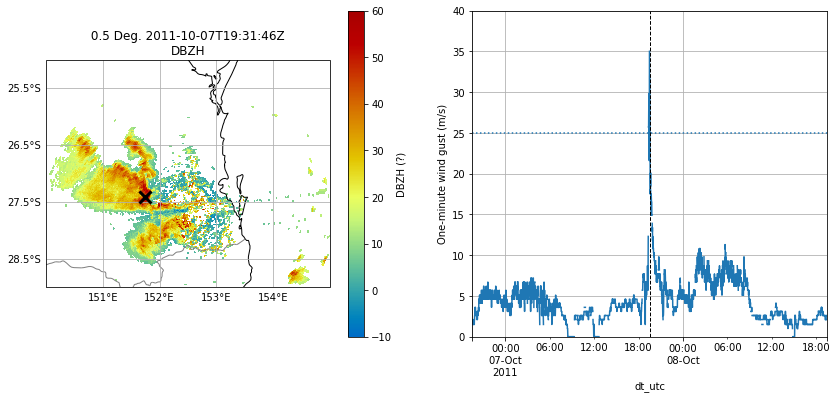

In [10]:
title = "Oakey 2011-10-07"
display(Markdown('<strong>{}</strong>'.format(title)))

stn_id=41359; lat=-27.4034; lon=151.7413; time = [dt.datetime(2011,10,7,19,30)]; delta_t = 24;
f = xr.open_dataset("/g/data/eg3/ab4502/ExtremeWind/aus/era5/era5_20111001_20111031.nc")
f_point = f.sel({"time":slice(time[0] - dt.timedelta(hours=delta_t), time[0] + dt.timedelta(hours=delta_t))})\
        .interp({"lat":lat, "lon":lon}, method="nearest")

plt.figure(figsize=[16,8])
plt.subplot(2,2,1); plot_era5_aws_ts(f_point, time)
plt.subplot(2,2,3); plot_era5_sta_ts(f_point, time)
plt.subplot(2,2,2); plot_other_indices(f_point, ["dcp", "scp", "wndg", "dmgwind"], time)
plt.subplot(2,2,4); plot_other_indices(f_point, ["mlcape*s06"], time)
plt.subplots_adjust(hspace=0.6)

plt.figure(figsize=[14,6])
ax1 = plt.subplot(121, projection=ccrs.PlateCarree())    
plot_era5_aws_spatial(f, time[0], ax1, lat, lon, domain="Brisbane")
ax2 = plt.subplot(122, projection=ccrs.PlateCarree())    
plot_era5_sta_spatial(f, time[0], ax2, lat, lon, domain="Brisbane")

plt.figure(figsize=[6,8])
plot_sounding(time[0],lat,lon)

plt.figure(figsize=[14,6])
plt.subplot(121,projection=ccrs.PlateCarree())
plot_radar("50", time[0], lon, lat, sweep=0)
plt.subplot(122)
df=plot_aws_gust(time[0], delta_t, stn_id, state="qld", vmax=40)

<strong>Archerfield 2014-11-27</strong>

INFO: LOADING RADAR FILE FOR ID 66 AND TIME 20141127


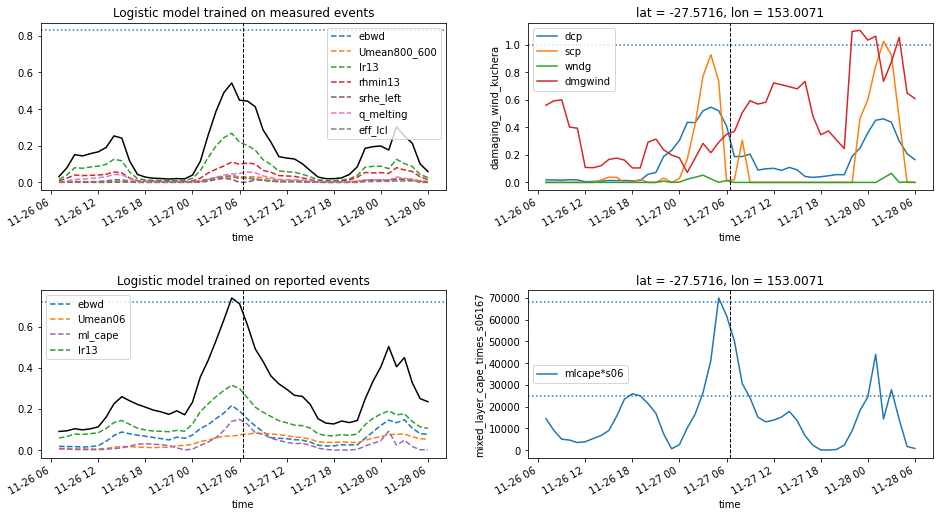

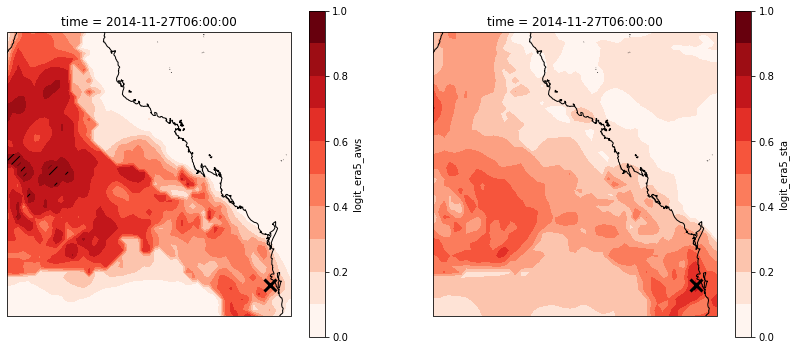

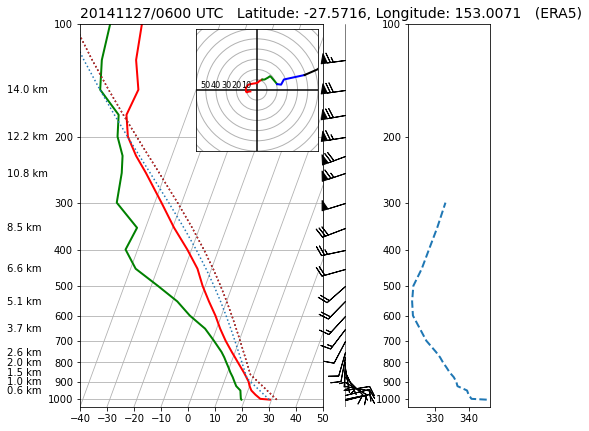

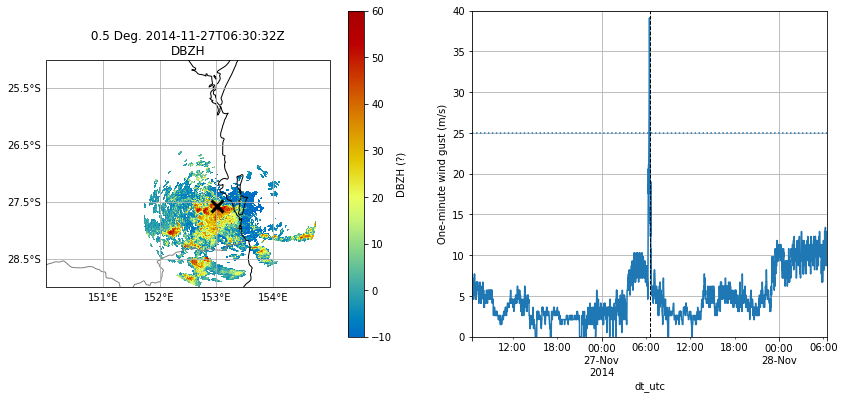

In [8]:
title = "Archerfield 2014-11-27"
display(Markdown('<strong>{}</strong>'.format(title)))

stn_id=40211; lat=-27.5716; lon=153.0071; time = [dt.datetime(2014,11,27,6,30)]; delta_t = 24;
f = xr.open_dataset("/g/data/eg3/ab4502/ExtremeWind/aus/era5/era5_20141101_20141130.nc")
f_point = f.sel({"time":slice(time[0] - dt.timedelta(hours=delta_t), time[0] + dt.timedelta(hours=delta_t))})\
        .interp({"lat":lat, "lon":lon}, method="nearest")

plt.figure(figsize=[16,8])
plt.subplot(2,2,1); plot_era5_aws_ts(f_point, time)
plt.subplot(2,2,3); plot_era5_sta_ts(f_point, time)
plt.subplot(2,2,2); plot_other_indices(f_point, ["dcp", "scp", "wndg", "dmgwind"], time)
plt.subplot(2,2,4); plot_other_indices(f_point, ["mlcape*s06"], time)
plt.subplots_adjust(hspace=0.6)

plt.figure(figsize=[14,6])
ax1 = plt.subplot(121, projection=ccrs.PlateCarree())    
plot_era5_aws_spatial(f, time[0], ax1, lat, lon, domain="Brisbane")
ax2 = plt.subplot(122, projection=ccrs.PlateCarree())    
plot_era5_sta_spatial(f, time[0], ax2, lat, lon, domain="Brisbane")

plt.figure(figsize=[6,8])
plot_sounding(time[0],lat,lon)

plt.figure(figsize=[14,6])
plt.subplot(121,projection=ccrs.PlateCarree())
plot_radar("66", time[0], lon, lat, sweep=0)
plt.subplot(122)
df=plot_aws_gust(time[0], delta_t, stn_id, state="qld", vmax=40)

INFO: LOADING RADAR FILE FOR ID 02 AND TIME 20210609


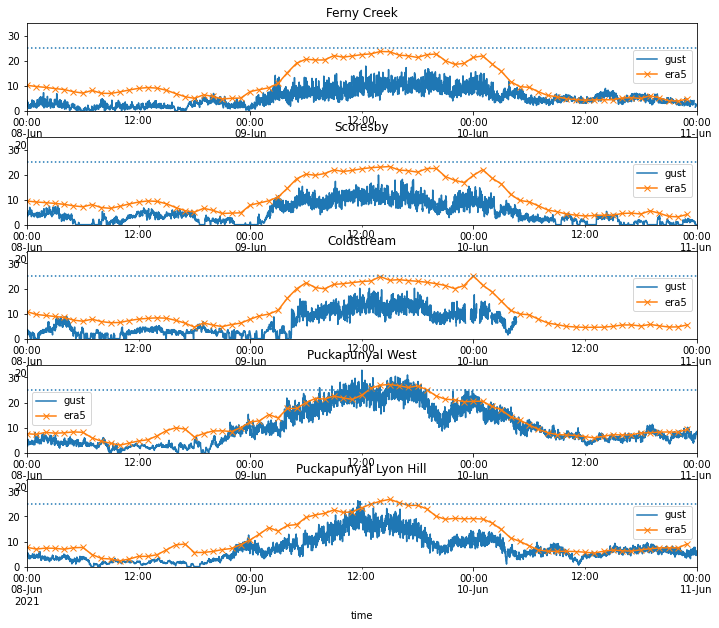

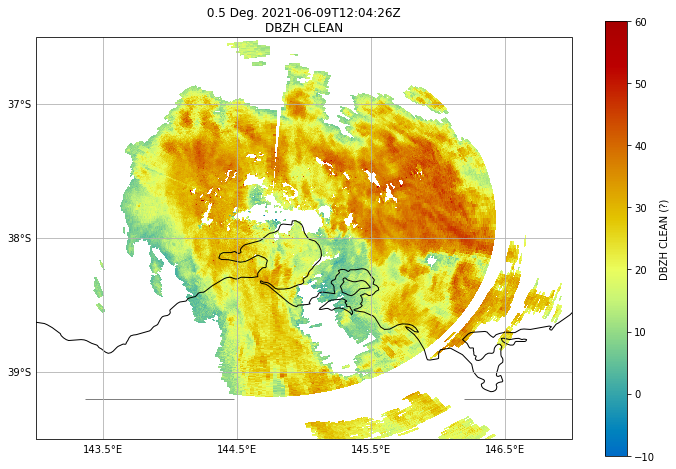

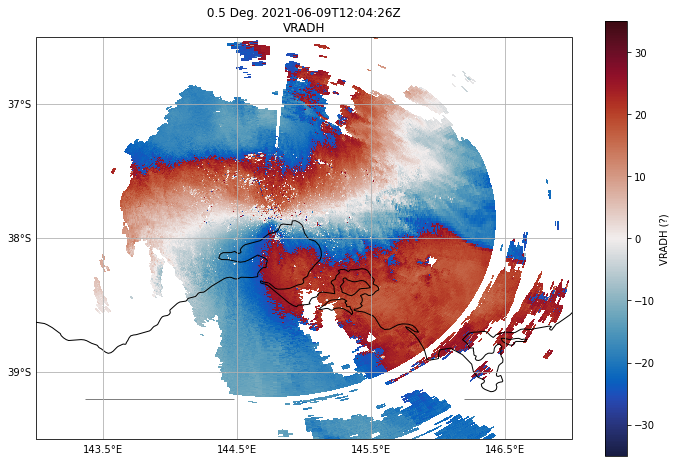

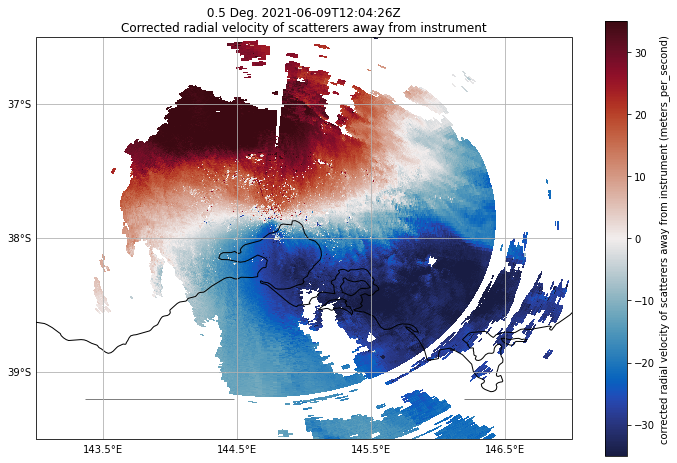

In [9]:
time = dt.datetime(2021,6,9,12); delta=36
f = xr.open_dataset("/g/data/eg3/ab4502/era5_download/dandenong_sfc.nc")
df = pd.read_csv("/g/data/eg3/ab4502/ExtremeWind/obs/aws/vic_one_min_gust/%s.csv" % (time.year))
df = df.set_index(pd.DatetimeIndex(df["dt_utc"]))
plt.figure(figsize=[12,10]);

plt.subplot(5,1,1); ax=plt.gca()
stn_id=86266; lat=-37.8738; lon=145.3497
df["dt_utc"] = pd.DatetimeIndex(df["dt_utc"])
df.query("stn_id==%s" % stn_id).loc[time - dt.timedelta(hours=delta) : time + dt.timedelta(hours=delta)].plot(x="dt_utc", y="gust",ax=ax)
pd.DataFrame({"time":pd.DatetimeIndex(f.time.values), "era5":f.interp({"latitude":lat, "longitude":lon})["fg10"].values}).plot(x="time", y="era5", ax=ax, marker="x")
plt.ylim([0,35]); ax.axhline(25, ls=":")
plt.title("Ferny Creek")

plt.subplot(5,1,2); ax=plt.gca()
stn_id=86104; lat=-37.8710; lon=145.2561
df["dt_utc"] = pd.DatetimeIndex(df["dt_utc"])
df.query("stn_id==%s" % stn_id).loc[time - dt.timedelta(hours=delta) : time + dt.timedelta(hours=delta)].plot(x="dt_utc", y="gust",ax=ax)
pd.DataFrame({"time":pd.DatetimeIndex(f.time.values), "era5":f.interp({"latitude":lat, "longitude":lon})["fg10"].values}).plot(x="time", y="era5", ax=ax, marker="x")
plt.ylim([0,35]); ax.axhline(25, ls=":")
plt.title("Scoresby")

plt.subplot(5,1,3); ax=plt.gca()
stn_id=86383; lat=-37.7239; lon=145.4092
df["dt_utc"] = pd.DatetimeIndex(df["dt_utc"])
df.query("stn_id==%s" % stn_id).loc[time - dt.timedelta(hours=delta) : time + dt.timedelta(hours=delta)].plot(x="dt_utc", y="gust",ax=ax)
pd.DataFrame({"time":pd.DatetimeIndex(f.time.values), "era5":f.interp({"latitude":lat, "longitude":lon})["fg10"].values}).plot(x="time", y="era5", ax=ax, marker="x")
plt.ylim([0,35]); ax.axhline(25, ls=":")
plt.title("Coldstream")

plt.subplot(5,1,4); ax=plt.gca()
stn_id=88166; lat=-37.0177; lon=144.8546
df["dt_utc"] = pd.DatetimeIndex(df["dt_utc"])
df.query("stn_id==%s" % stn_id).loc[time - dt.timedelta(hours=delta) : time + dt.timedelta(hours=delta)].plot(x="dt_utc", y="gust",ax=ax)
pd.DataFrame({"time":pd.DatetimeIndex(f.time.values), "era5":f.interp({"latitude":lat, "longitude":lon})["fg10"].values}).plot(x="time", y="era5", ax=ax, marker="x")
plt.ylim([0,35]); ax.axhline(25, ls=":")
plt.title("Puckapunyal West")

plt.subplot(5,1,5); ax=plt.gca()
stn_id=88167; lat=-36.9381; lon=145.0539
df["dt_utc"] = pd.DatetimeIndex(df["dt_utc"])
df.query("stn_id==%s" % stn_id).loc[time - dt.timedelta(hours=delta) : time + dt.timedelta(hours=delta)].plot(x="dt_utc", y="gust",ax=ax)
pd.DataFrame({"time":pd.DatetimeIndex(f.time.values), "era5":f.interp({"latitude":lat, "longitude":lon})["fg10"].values}).plot(x="time", y="era5", ax=ax, marker="x")
plt.ylim([0,35]); ax.axhline(25, ls=":")
plt.title("Puckapunyal Lyon Hill")
plt.subplots_adjust(hspace=0.3)

radar = load_radar("02", dt.datetime(2021,6,9,12))
dealiased = pyart.correct.dealias_region_based(radar, vel_field="VRADH", nyquist_vel=26.38)
radar.add_field('VRADH_DEALIASED', dealiased, replace_existing=True)

disp=pyart.graph.RadarMapDisplay(radar)
plt.figure(figsize=[12,8])
plt.subplot(111,projection=ccrs.PlateCarree())
disp.plot_ppi_map("DBZH_CLEAN",13, resolution="10m", vmin=-10, vmax=60,cmap=pyart.graph.cm_colorblind.HomeyerRainbow,
                    min_lon=143, max_lon=147, min_lat=-39.5, max_lat=-36.5,
                     lon_lines=[143.5,144.5,145.5,146.5], lat_lines=[-39, -38, -37])

plt.figure(figsize=[12,8])
plt.subplot(111,projection=ccrs.PlateCarree())
disp.plot_ppi_map("VRADH",13, resolution="10m", vmin=-35, vmax=35,cmap='pyart_balance',
                    min_lon=143, max_lon=147, min_lat=-39.5, max_lat=-36.5,
                     lon_lines=[143.5,144.5,145.5,146.5], lat_lines=[-39, -38, -37])

plt.figure(figsize=[12,8])
plt.subplot(111,projection=ccrs.PlateCarree())
disp.plot_ppi_map("VRADH_DEALIASED",13, resolution="10m", vmin=-35, vmax=35,cmap='pyart_balance',
                    min_lon=143, max_lon=147, min_lat=-39.5, max_lat=-36.5,
                     lon_lines=[143.5,144.5,145.5,146.5], lat_lines=[-39, -38, -37])